### Setup

In [2]:
import os
import torch
import torch.nn as nn
from tqdm.notebook import tqdm, trange
import torch.optim as optim
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from PIL import Image
from pathlib import Path
import numpy as np
from sklearn.model_selection import train_test_split
import random
import pickle
import datetime
import math
from pathlib import Path
import re
import json
import glob
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True  # Enforce deterministic algorithms
        torch.backends.cudnn.benchmark = False     # Disable benchmark for reproducibility

    os.environ['PYTHONHASHSEED'] = str(seed)       # Seed Python hashing, which can affect ordering

SEED=42
set_seed(SEED)

LABEL_COLS = [
    "Vaccum Cleaning", "Mopping the Floor", "Carry Warm Food",
    "Carry Cold Food", "Carry Drinks", "Carry Small Objects",
    "Carry Large Objects", "Cleaning", "Starting a conversation"
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import sys
sys.path.append('..')

from data_processing.data_utils import get_transform, deserialize_transform, get_domain_dataloaders, pool_domain_dataloaders, get_crossvalidation_domain_loaders, IMAGENET_NORM, get_domain_dataloaders_from_hdf5
from models.heuristicSplitModel import DualBranchModel, DualBranchModel_fusions

### model checkpoints

In [221]:
files = {    
    'dual_joint_fold=4.base':'../checkpoints/disentanglement_joint_noreplay.base_fold=4_buffer_size=120_epochs=60_seed=42_20260114_053954_config.json',
    'dual_joint_fold=3.base':'../checkpoints/disentanglement_joint_noreplay.base_fold=3_buffer_size=120_epochs=60_seed=42_20260114_052414_config.json',
    'dual_joint_fold=2.base':'../checkpoints/disentanglement_joint_noreplay.base_fold=2_buffer_size=120_epochs=60_seed=42_20260114_050925_config.json',
    'dual_joint_fold=1.base':'../checkpoints/disentanglement_joint_noreplay.base_fold=1_buffer_size=120_epochs=60_seed=42_20260114_045256_config.json',
    'dual_joint_fold=0.base':'../checkpoints/disentanglement_joint_noreplay.base_fold=0_buffer_size=120_epochs=60_seed=42_20260114_043600_config.json',
    'single_joint_fold=4.nomask':'../checkpoints/nodisentanglement_joint_noreplay.nomask_fold=4_buffer_size=120_epochs=60_seed=42_20260114_042526_config.json',
    'single_joint_fold=3.nomask':'../checkpoints/nodisentanglement_joint_noreplay.nomask_fold=3_buffer_size=120_epochs=60_seed=42_20260114_041449_config.json',
    'single_joint_fold=2.nomask':'../checkpoints/nodisentanglement_joint_noreplay.nomask_fold=2_buffer_size=120_epochs=60_seed=42_20260114_040515_config.json',
    'single_joint_fold=1.nomask':'../checkpoints/nodisentanglement_joint_noreplay.nomask_fold=1_buffer_size=120_epochs=60_seed=42_20260114_035439_config.json',
    'single_joint_fold=0.nomask':'../checkpoints/nodisentanglement_joint_noreplay.nomask_fold=0_buffer_size=120_epochs=60_seed=42_20260114_034453_config.json',
}

In [ ]:
files = {
    'order_contrB_fold=4.base':'../checkpoints/order_contrB.base_fold=4_buffer_size=60_epochs=60_seed=42_20260221_010240_config.json',
    'order_contrB_fold=3.base':'../checkpoints/order_contrB.base_fold=3_buffer_size=60_epochs=60_seed=42_20260221_003730_config.json',
    'order_contrB_fold=2.base':'../checkpoints/order_contrB.base_fold=2_buffer_size=60_epochs=60_seed=42_20260221_001212_config.json',
    'order_contrB_fold=1.base':'../checkpoints/order_contrB.base_fold=1_buffer_size=60_epochs=60_seed=42_20260220_223136_config.json',
    'order_contrB_fold=0.base':'../checkpoints/order_contrB.base_fold=0_buffer_size=60_epochs=60_seed=42_20260220_024416_config.json',

    'order_contrA_fold=4.base':'../checkpoints/order_contrA.base_fold=4_buffer_size=60_epochs=60_seed=42_20260220_220244_config.json',
    'order_contrA_fold=3.base':'../checkpoints/order_contrA.base_fold=3_buffer_size=60_epochs=60_seed=42_20260220_214104_config.json',
    'order_contrA_fold=2.base':'../checkpoints/order_contrA.base_fold=2_buffer_size=60_epochs=60_seed=42_20260220_170919_config.json',
    'order_contrA_fold=1.base':'../checkpoints/order_contrA.base_fold=1_buffer_size=60_epochs=60_seed=42_20260220_164509_config.json',
    'order_contrA_fold=0.base':'../checkpoints/order_contrA.base_fold=0_buffer_size=60_epochs=60_seed=42_20260220_022218_config.json',

    'order_complexdown_fold=4.base':'../checkpoints/order_complexdown.base_fold=4_buffer_size=60_epochs=60_seed=42_20260220_162058_config.json',
    'order_complexdown_fold=3.base':'../checkpoints/order_complexdown.base_fold=3_buffer_size=60_epochs=60_seed=42_20260220_155008_config.json',
    'order_complexdown_fold=2.base':'../checkpoints/order_complexdown.base_fold=2_buffer_size=60_epochs=60_seed=42_20260220_152548_config.json',
    'order_complexdown_fold=1.base':'../checkpoints/order_complexdown.base_fold=1_buffer_size=60_epochs=60_seed=42_20260220_145846_config.json',
    'order_complexdown_fold=0.base':'../checkpoints/order_complexdown.base_fold=0_buffer_size=60_epochs=60_seed=42_20260220_015920_config.json',

    'order_complexup_fold=4.base':'../checkpoints/order_complexup.base_fold=4_buffer_size=60_epochs=60_seed=42_20260220_143633_config.json',
    'order_complexup_fold=3.base':'../checkpoints/order_complexup.base_fold=3_buffer_size=60_epochs=60_seed=42_20260220_141409_config.json',
    'order_complexup_fold=2.base':'../checkpoints/order_complexup.base_fold=2_buffer_size=60_epochs=60_seed=42_20260220_134857_config.json',
    'order_complexup_fold=1.base':'../checkpoints/order_complexup.base_fold=1_buffer_size=60_epochs=60_seed=42_20260220_132550_config.json',
    'order_complexup_fold=0.base':'../checkpoints/order_complexup.base_fold=0_buffer_size=60_epochs=60_seed=42_20260220_013501_config.json',


    'closeup_fold=4.base':'../checkpoints/closeup.base_fold=4_buffer_size=60_epochs=60_seed=42_20260220_130731_config.json',
    'closeup_fold=3.base':'../checkpoints/closeup.base_fold=3_buffer_size=60_epochs=60_seed=42_20260220_125025_config.json',
    'closeup_fold=2.base':'../checkpoints/closeup.base_fold=2_buffer_size=60_epochs=60_seed=42_20260220_123209_config.json',
    'closeup_fold=1.base':'../checkpoints/closeup.base_fold=1_buffer_size=60_epochs=60_seed=42_20260220_120940_config.json',
    'closeup_fold=0.base':'../checkpoints/closeup.base_fold=0_buffer_size=60_epochs=60_seed=42_20260220_011600_config.json',

    'silh_fold=4.base':'../checkpoints/silh.base_fold=4_buffer_size=60_epochs=60_seed=42_20260220_114438_config.json',
    'silh_fold=3.base':'../checkpoints/silh.base_fold=3_buffer_size=60_epochs=60_seed=42_20260220_112012_config.json',
    'silh_fold=2.base':'../checkpoints/silh.base_fold=2_buffer_size=60_epochs=60_seed=42_20260220_105716_config.json',
    'silh_fold=1.base':'../checkpoints/silh.base_fold=1_buffer_size=60_epochs=60_seed=42_20260220_103456_config.json',
    'silh_fold=0.base':'../checkpoints/silh.base_fold=0_buffer_size=60_epochs=60_seed=42_20260220_005210_config.json',

    'single_cl_b60_fold=4.nomask':'../checkpoints/single_b60.nomask_fold=4_buffer_size=60_epochs=60_seed=42_20260218_053056_config.json',
    'single_cl_b60_fold=3.nomask':'../checkpoints/single_b60.nomask_fold=3_buffer_size=60_epochs=60_seed=42_20260218_051622_config.json',
    'single_cl_b60_fold=2.nomask':'../checkpoints/single_b60.nomask_fold=2_buffer_size=60_epochs=60_seed=42_20260218_050330_config.json',
    'single_cl_b60_fold=1.nomask':'../checkpoints/single_b60.nomask_fold=1_buffer_size=60_epochs=60_seed=42_20260218_044955_config.json',
    'single_cl_b60_fold=0.nomask':'../checkpoints/single_b60.nomask_fold=0_buffer_size=60_epochs=60_seed=42_20260218_043141_config.json',

    'dual_cl_b60_fold=4.base':'../checkpoints/default_b60.base_fold=4_buffer_size=60_epochs=60_seed=42_20260218_040948_config.json',
    'dual_cl_b60_fold=3.base':'../checkpoints/default_b60.base_fold=3_buffer_size=60_epochs=60_seed=42_20260218_034725_config.json',
    'dual_cl_b60_fold=2.base':'../checkpoints/default_b60.base_fold=2_buffer_size=60_epochs=60_seed=42_20260218_032532_config.json',
    'dual_cl_b60_fold=1.base':'../checkpoints/default_b60.base_fold=1_buffer_size=60_epochs=60_seed=42_20260218_030445_config.json',
    'dual_cl_b60_fold=0.base':'../checkpoints/default_b60.base_fold=0_buffer_size=60_epochs=60_seed=42_20260218_024124_config.json',

}

### Model loading utils

In [49]:
def get_extra_resize_transforms(hdf5_path, img_path_cols, serialised_transforms):
    """
    If serialised resize from training config is different from default hdf5 stored image size, returns the extra resize.
    Do not allow for upsampling! Only downsizing.
    """
    import h5py
    
    resizes_out = []
    with h5py.File(hdf5_path, "r") as f:
        for img_col, serialized_pipeline in zip(img_path_cols, serialised_transforms):

            # get stored size
            dset = f[f"Home/train/images/{img_col}"]
            stored_h, stored_w = dset.shape[-2:]

            # get resize from serialized transform
            resize = next(step for step in serialized_pipeline if step['type'] == 'Resize')
            target_h, target_w = resize['args']['size']

            if (stored_h, stored_w) == (target_h, target_w):
                resizes_out.append(None)
            elif target_h > stored_h or target_w > stored_w:
                raise ValueError(f"Upsampling attempted: stored=({stored_h},{stored_w}) target=({target_h},{target_w})")
            else:
                resizes_out.append(deserialize_transform([resize]))

        return resizes_out

In [50]:
def get_ablation_dataloader(ablation, train_val_dataset, test_dataset, hdf5_dataset, img_path_cols, serialized_transforms, scene_as_label=False, domains=None, joint_training=False):        

    if ablation not in ('base', 'nomask', 'onlyenv', 'onlysoc'):
        raise ValueError("Wrong ablation. Has to be one of ('base', 'nomask', 'onlyenv', 'onlysoc')")
    
    if ablation == 'base' and not scene_as_label:
        cols=img_path_cols
        trans=serialized_transforms
    elif ablation == 'onlyenv' and scene_as_label:
        cols=[]
        trans=[]
    else:
        cols=[img_path_cols[0]]
        trans=[serialized_transforms[0]]

    if hdf5_dataset:
        extra_trans = get_extra_resize_transforms(hdf5_dataset, cols, trans)
        if any(extra_trans):
            print("Applying extra transformation",extra_trans)
        domain_dataloaders = get_domain_dataloaders_from_hdf5(hdf5_path=hdf5_dataset, domains=domains, img_path_cols=cols, set_first_element_as_domain_label=scene_as_label, transforms=extra_trans)
    else:
        trans = [deserialize_transform(x) for x in trans]
        domain_dataloaders = get_domain_dataloaders(train_val_dataset, seed=SEED, batch_sizes=(32, 64, 64), img_path_cols=cols, transforms=trans, include_test=test_dataset, set_first_element_as_domain_label=scene_as_label)
        
    # if joint_training:
    #     domain_dataloaders = pool_domain_dataloaders(domain_dataloaders)
    
    return domain_dataloaders

In [51]:
#-------------LEGACY-----------------
# def legacy_get_ablation_dataloader(ablation, dataset_path="../data/pepper_data_train.pkl", transform=None, include_test=None, lgr=False):
#     df = pd.read_pickle(dataset_path)
#     transform = transform or T.Compose([
#             T.Resize((144,256)),
#             T.ToTensor(),
#             T.Normalize(mean=[0.485, 0.456, 0.406], 
#                                 std=[0.229, 0.224, 0.225])
#         ])
#     if lgr:
#         transform = T.Compose([
#             T.Resize((128, 128)),
#             T.ToTensor(),
#             T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
#         ])
#         ablation = 'nomask'

#     if 'base' in ablation:
#         domain_dataloaders = get_domain_dataloaders(df, batch_sizes=(32, 64, 64), double_img=True, transforms=[transform]*2, num_workers=0, include_test=include_test)
#     elif 'nomask' in ablation:
#         domain_dataloaders = get_domain_dataloaders(df, batch_sizes=(32, 64, 64), double_img=False, transforms=transform, num_workers=0, include_test=include_test)
#     elif 'onlysoc' in ablation:
#         df['image_path'] = df['image_path_soc']
#         domain_dataloaders = get_domain_dataloaders(df, batch_sizes=(32, 64, 64), double_img=False, transforms=transform, num_workers=0, include_test=include_test)
#     elif 'onlyenv' in ablation:
#         df['image_path'] = df['image_path_env']
#         domain_dataloaders = get_domain_dataloaders(df, batch_sizes=(32, 64, 64), double_img=False, transforms=transform, num_workers=0, include_test=include_test)

#     elif 'nocl' in ablation:
#         domain_dataloaders = get_domain_dataloaders(df, batch_sizes=(32, 64, 64), double_img=True, transforms=[transform]*2, num_workers=0, include_test=include_test)
#         domain_dataloaders = combine_all_dataloaders(domain_dataloaders)
    
#     return domain_dataloaders

In [52]:
def load_model_from_checkpoint(checkpoint_file_path, config, device):
    pt_file = torch.load(checkpoint_file_path)
    model = DualBranchModel(dropout_rate=config['model']['dropout_rate'], setup=config['model']['setup'], branch_norm=config['model']['branch_norm'])
    model = model.to(device)
    model.load_state_dict(pt_file['model_state_dict'])
    history = pt_file['history']
    earlystop_epoch = pt_file.get('epoch')
    return model, history, earlystop_epoch


In [53]:
# ---------- LEGACY --------------

# def load_model_from_checkpoint(branch, ablation, checkpoint_file_path, device):
#     pt_file = torch.load(checkpoint_file_path)
#     branch_norm = False #True if 'branch' in ablation else False
#     norm_type = 'layer' # if 'layer' in ablation else 'batch'
#     freeze_branches = False
#     # ablation = 'onlysoc'
#     setup = {'branch': branch} if 'base' in ablation else {'branch': branch, 'env': 'ablated'}
#     # print(branch, ablation, setup, branch_norm, freeze_branches, norm_type)
#     model = DualBranchModel_old(dropout_rate=0.3, setup=setup, branch_norm=branch_norm, freeze_branches=freeze_branches, norm_type=norm_type)
#     model = model.to(device)
#     model.load_state_dict(pt_file['model_state_dict'])
#     history = pt_file['history']
#     earlystop_epoch = pt_file.get('epoch')
#     # tsne_data = pt_file.get('tsne')
#     return model, history, earlystop_epoch

In [54]:
def perturb_test(perturbation):
    test_df = pd.read_pickle("../data/pepper_data_test_equal.pkl")
    options = {
        '.env': ('image_path_env','../data/perturbations/environment/'),
        '.socnorobot': ('image_path_social','../data/perturbations/social_norobot/'),
        '.socnoppl': ('image_path_social','../data/perturbations/social_noppl/'),
        '.nosoc': ('image_path_social','../data/perturbations/blank.png'),
        '.noenv': ('image_path_env','../data/perturbations/blank.png'),
    }
    col, perturbation_path = options[perturbation]
    test_df['image_path'] = test_df['image_path'].str.replace(
            r"^../data/images/",
            perturbation_path,
            regex=True
        )
    test_df[col] = test_df['image_path']

    if perturbation in ['.nosoc','.noenv']:
        test_df[col] = "../data/perturbations/blank.png"
    return test_df

In [55]:
def get_checkpoint_stem_path(file_path):
    file_path = Path(file_path)
    TS_RE = re.compile(r'^(.*_\d{8}_\d{6})') # timestamp is the last valid part of stem
    stem = TS_RE.match(file_path.stem).group(1)
    checkpoint_stem_path = (file_path.parent / stem).as_posix()

    return checkpoint_stem_path


In [56]:
def load_models(models_to_load, verbose=False):
    """
    Given dict like {model name: model config file}
    For each model, using the config file:
    1. recreate the model and load it into memory with last checkpoint weights
    2. recreate its dataloader
    """
    models = {}
    for name, file_path in tqdm(models_to_load.items()):
        with open(file_path, "r") as f:
            config = json.load(f)

        domains = config['domains_order']
        joint_training = config['joint_training']
        if verbose: print(f"{domains=}\n{joint_training=}")

        # Get last model checkpoint path
        checkpoint_stem_path = get_checkpoint_stem_path(file_path)
        checkpoint_suffix = ('_domainjoint' if joint_training else '_domain' + domains[-1]) + '.pt'
        last_checkpoint_path = checkpoint_stem_path + checkpoint_suffix
        if verbose: print(f"{checkpoint_stem_path=}\n{checkpoint_suffix=}\n{last_checkpoint_path=}")

        model, history, earlystop_epoch = load_model_from_checkpoint(last_checkpoint_path, config, DEVICE)

        ablation = name.split('.')[1]
        train_val_df = pd.read_pickle(config['train_val_df']) if config['train_val_df'] is not None else None
        test_df = pd.read_pickle(config['test_df']) if config['test_df'] is not None else None
        hdf5_dataset_path = config['hdf5_dataset_path']

        # TEMPORARY WORKAROUND
        fold_num = name.split('.')[0].split('_fold=')[1]
        if 'robotfocus128_pepper_data' in hdf5_dataset_path:
            hdf5_dataset_path = f"../data/robotfocus128_pepper_data_fold{fold_num}.hdf5"
        else:
            hdf5_dataset_path = f"../data/mean_data_pepper_fold{fold_num}.hdf5"

        serialized_transform_list = config['input_transforms'] #[deserialize_transform(x) for x in config['input_transforms']]
        img_path_cols = config['input_columns']
        if verbose: print(f"{ablation=}\n{config['train_val_df']=}\n{config['test_df']=}\n{hdf5_dataset_path=}\n{serialized_transform_list=}\n{img_path_cols=}")

        dataloader = get_ablation_dataloader(ablation, train_val_dataset=train_val_df, test_dataset=test_df, hdf5_dataset=hdf5_dataset_path, img_path_cols=img_path_cols, serialized_transforms=serialized_transform_list, scene_as_label=config['model']['setup'].get('scene') == 'label', domains=domains, joint_training=joint_training)

        models[name] = (model, history, dataloader, earlystop_epoch)

    return models

In [57]:
def legacy_load_models(models_to_load):
    models = {}
    for name, file_path in tqdm(models_to_load.items()):
        variant, ablation = name.split('.')
        base = re.sub(r'_(\d{8}_\d{6}).*', r'_\1', file_path)
        with open(f"{base}_config.json", "r") as f:
            config = json.load(f)
        model, history, earlystop_epoch = load_model_from_checkpoint(file_path, config, DEVICE)

        # if 'robotfocus' in variant:
        #     train_val_df = pd.read_pickle("../data/robotfocus_pepper_data_train.pkl")
        #     test_df = pd.read_pickle("../data/robotfocus_pepper_data_test_equal.pkl")
        # else:
        #     train_val_df = pd.read_pickle("../data/pepper_data_train.pkl")
        #     test_df = pd.read_pickle("../data/pepper_data_test.pkl")
        train_val_df = pd.read_pickle(config['train_val_df']) if config['train_val_df'] is not None else None
        test_df = pd.read_pickle(config['test_df']) if config['test_df'] is not None else None
        hdf5_dataset_path = config['hdf5_dataset_path']
        domains = config.get('domains_order', ['Home', 'BigOffice-2', 'BigOffice-3', 'Hallway', 'MeetingRoom', 'SmallOffice'])
            
        transform_list = [deserialize_transform(x) for x in config['input_transforms']]
        img_path_cols = config['input_columns']
        # transform_list = [transform_scene, transform_scene]
        # img_path_cols = ['image_path_env', 'image_path_soc']
        # print(name, config['input_columns'], transform_list)
        # print(config['train_val_df'], config['test_df'])
        # print(config.get('domains_order'))
        joint_training = config.get('joint_training') or config.get('training_mode') == 'noCL'
        
            
        dataloader = get_ablation_dataloader(ablation, train_val_dataset=train_val_df, test_dataset=test_df, hdf5_dataset=hdf5_dataset_path, img_path_cols=img_path_cols, transforms=transform_list, scene_as_label=config['model']['setup'].get('scene') == 'label', domains=domains, joint_training=joint_training)
        # scene_as_label=config['model']['setup'].get('scene') == 'label'
        # transforms=transform_list
        # if ablation == 'base':
        #     if scene_as_label:
        #         cols=[img_path_cols[0]]
        #         trans=[transforms[0]]
        #     else:
        #         cols=[img_path_cols[0], img_path_cols[1]]
        #         trans=[transforms[0], transforms[1]]
        # elif ablation == 'nomask':
        #     cols=[img_path_cols[0]]
        #     trans=[transforms[0]]
        # elif ablation == 'onlyenv':
        #     if scene_as_label:
        #         cols=[]
        #         trans=[]
        #     else:
        #         cols=[img_path_cols[0]]
        #         trans=[transforms[0]]
        # elif ablation == 'onlysoc':
        #     cols=[img_path_cols[0]]
        #     trans=[transforms[0]]
        # fold_dataloaders = get_crossvalidation_domain_loaders(train_val_df, folds=5, seed=42, batch_sizes=(32,64,64), img_path_cols=cols, transforms=transforms, num_workers=0, set_first_element_as_domain_label=scene_as_label, pin_memory=True)
        # fold = int(re.search(r'fold=(\d+)', file_path).group(1))
        # dataloader = fold_dataloaders[fold]
        models[name] = (model, history, dataloader, earlystop_epoch)

    return models

In [58]:
# ------------- LEGACY model loading script ------------------

# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# models = {}
# for name, file_path in tqdm(files.items()):
#     # branch, ablation = name.split('_')
#     branch, ablation = ('mobilenetv2', 'onlysoc')

#     test_df = pd.read_pickle("../data/pepper_data_test_equal.pkl")
#     test_df['image_path'] = test_df['image_path_soc']
#     # test_df = perturb_test(ablation.removeprefix('perturbations'))
#     # branch = 'mobilenetv2'
#     # ablation = 'base'

#     # ablation = ablation.removeprefix("ablation") if 'ablation' in ablation else 'base'

#     model, history, earlystop_epoch = load_model_from_checkpoint(branch, ablation, file_path, DEVICE)
#     # ablation = 'onlysoc'

#     dataloader = legacy_get_ablation_dataloader(ablation, transform=None, include_test=test_df)
#     models[name] = (model, history, dataloader, earlystop_epoch)

### Load models into memory

In [59]:
import warnings

try:
    models = load_models(files, verbose=False)
except Exception as e:
    print('Warning! Legacy fallback')
    warnings.warn("JSON-based model loading failed. Falling back to legacy loader.", RuntimeWarning)
    
    models = legacy_load_models(files)
    raise RuntimeError("JSON-based loading failed; legacy loader was used.") from e
   

  0%|          | 0/4 [00:00<?, ?it/s]

### Evaluation utils

#### CL metrics

In [70]:
import math

def convert_rmse_curve(mse_list, scale_factor=4):
    return [math.sqrt(mse) * scale_factor for mse in mse_list]

def convert_rmse_cross_domain(cross_domain_list, scale_factor=4):
    """DO NOT AGREAGATE. RMSE is not linear. sqrt(mean(MSE)) != mean(sqrt(MSE))"""
    rmse_list = []
    for mse_dict in cross_domain_list:
        rmse_dict = {domain: math.sqrt(mse) * scale_factor for domain, mse in mse_dict.items()}
        rmse_list.append(rmse_dict)
    return rmse_list

def get_cl_matrix(cross_domain_dicts):
    # cross_domain_dicts: a list of dicts
    domains = list(cross_domain_dicts[-1].keys())
    N = len(domains)
    steps = len(cross_domain_dicts)

    # Build square numpy matrix
    matrix = np.full((steps, N), np.nan)
    for i, checkpoint in enumerate(cross_domain_dicts):
        for j, dom in enumerate(domains):
            if dom in checkpoint:
                matrix[i, j] = checkpoint[dom]
    return matrix

In [71]:
def lesort_acc(matrix):
    vals = []
    for i in range(matrix.shape[0]):
        for j in range(i + 1):  # i >= j
            if not np.isnan(matrix[i, j]):
                vals.append(matrix[i, j])
    return np.mean(vals)

def final_acc(matrix):
    return np.nanmean(matrix[-1, :])

def lesort_bwt(matrix):
    vals = []
    for i in range(1, matrix.shape[0]):    # i=1..N-1 (python indices)
        for j in range(i):                 # j=0..i-1
            if not np.isnan(matrix[i, j]) and not np.isnan(matrix[j, j]):
                baseline = matrix[j, j]
                vals.append(matrix[i, j] - baseline)
    return np.mean(vals) if vals else np.nan

def lesort_bwt_normalized(matrix):
    vals = []
    perfect_cases = []
    for i in range(1, matrix.shape[0]):    
        for j in range(i):                
            if not np.isnan(matrix[i, j]) and not np.isnan(matrix[j, j]):
                baseline = matrix[j, j]
                if baseline == 0:
                    perfect_cases.append((i, j, matrix[i, j]))  # Track: (checkpoint, domain, later_rmse)
                else:
                    vals.append((matrix[i, j] - baseline) / baseline)
    
    if perfect_cases:
        warnings.warn(
            f"Found {len(perfect_cases)} perfect baseline cases (RMSE=0). "
            f"These were excluded from normalized BWT. Examples: {perfect_cases[:3]}. "
            f"Consider raw BWT if perfect performance is common."
        )
    
    return np.mean(vals) if vals else np.nan

def lesort_fwt(matrix):
    vals = []
    n = matrix.shape[0]
    for j in range(1, n):   # j=1..N-1
        for i in range(j):  # i=0..j-1
            if not np.isnan(matrix[i, j]):
                vals.append(matrix[i, j])
    return np.mean(vals) if vals else np.nan

In [72]:
def bwt_for_domains(matrix, domain_indices):
    M_sub = np.full_like(matrix, np.nan)
    M_sub[:, domain_indices] = matrix[:, domain_indices]
    return lesort_bwt(M_sub)

def per_domain_bwt(matrix):
    """
    Per-domain BWT:
    for each domain d (column d), average over (performance at later steps - baseline at its own step).
    Returns a 1D array of length D.
    """
    T, D = matrix.shape
    bwt_per_domain = np.full(D, np.nan)

    for d in range(D):
        baseline = matrix[d, d]
        if np.isnan(baseline):
            continue
        diffs = []
        for t in range(d+1, T):  # later steps
            if not np.isnan(matrix[t, d]):
                diffs.append(matrix[t, d] - baseline)
        if diffs:
            bwt_per_domain[d] = np.mean(diffs)

    return bwt_per_domain

def stepwise_fwt(matrix):
    """
    FWT after each step t:
    at step t, average performance on all future domains j > t.
    Returns a 1D array of length T-1, where entry t is FWT at step t.
    """
    T, D = matrix.shape
    fwt_steps = np.full(T-1, np.nan)

    for t in range(T-1):  # last step has no future domains
        future_vals = []
        for j in range(t+1, D):
            if not np.isnan(matrix[t, j]):
                future_vals.append(matrix[t, j])
        if future_vals:
            fwt_steps[t] = np.mean(future_vals)

    return fwt_steps


#### inference

In [73]:
def infer(model, device, domain_dataloaders, eval_subset='val'):
    all_domain_preds = []
    all_domain_labels = []

    model.eval()
    with torch.no_grad():
        for domain, loaders in tqdm(domain_dataloaders.items()):
            domain_preds = []
            domain_labels = []
            for batch in loaders[eval_subset]:
                inputs, labels, _ = batch
                inputs = tuple(x.to(device) for x in inputs)
                labels = labels.to(device)
                
                outputs = model(*inputs)['output']

                domain_preds.append(outputs.cpu().numpy())
                domain_labels.append(labels.cpu().numpy())

            domain_preds = np.vstack(domain_preds)
            domain_labels = np.vstack(domain_labels)
            all_domain_preds.append(domain_preds)
            all_domain_labels.append(domain_labels)
    all_preds = np.vstack(all_domain_preds)
    all_labels = np.vstack(all_domain_labels)
    return all_preds, all_labels

In [74]:
def infer_per_domain(model, device, domain_dataloaders, eval_subset='val'):
    domain_data = {}
    domain_h = {}
    model.eval()
    with torch.no_grad():
        for domain, loaders in domain_dataloaders.items():
            domain_preds = []
            domain_labels = []
            domain_h_e = []
            domain_h_s = []
            for batch in loaders[eval_subset]:

                inputs, labels, _ = batch
                inputs = tuple(x.to(device) for x in inputs)
                labels = labels.to(device)

                outputs = model(*inputs)
                preds = outputs['output']
                domain_preds.append(preds.detach())
                domain_labels.append(labels.detach())
                # h_e = outputs['scene_feats']
                # h_s = outputs['focus_feats']
                # domain_h_e.append(h_e.detach())
                # domain_h_s.append(h_s.detach())
                

            domain_preds = torch.vstack(domain_preds).cpu()
            domain_labels = torch.vstack(domain_labels).cpu()
            # domain_h_e = torch.vstack(domain_h_e).cpu()
            # domain_h_s = torch.vstack(domain_h_s).cpu()
            
            domain_data[domain] = (domain_preds, domain_labels)
            # domain_h[domain] = (domain_h_e, domain_h_s)
    
    return domain_data#, domain_h

def aggregate_domain_data(domain_data):
    all_preds = []
    all_labels = []
    
    for _, (preds, labels) in domain_data.items():
        all_preds.append(preds)
        all_labels.append(labels)
    
    all_preds = torch.vstack(all_preds)
    all_labels = torch.vstack(all_labels)
    
    return all_preds, all_labels


#### performance metrics

In [75]:
import torch
import torch.nn.functional as F
from torchmetrics.functional.regression import pearson_corrcoef, concordance_corrcoef
from typing import Literal

def check_tensor_range(x: torch.Tensor, name="tensor"):
    min_v = x.min().item()
    max_v = x.max().item()

    if min_v < 0 or max_v > 1:
        warnings.warn(
            f"Potentialy scaled tensor: "
            f"{name} has values outside expected [0, 1] "
            f"(min={x.min().item():.3f}, max={x.max().item():.3f})"
        )

def pool_correlations(corr_tensor: torch.Tensor) -> torch.Tensor:
    """
    Pool a 1D tensor of correlations via Fisher’s Z transform.
    """
    x = corr_tensor.clamp(-0.999999, 0.999999)
    z = torch.atanh(x)
    z_mean = z.mean()
    pooled_corr = torch.tanh(z_mean)
    return pooled_corr

def get_metrics(
    preds: torch.Tensor,
    targets: torch.Tensor,
    transpose: bool = True,
    agg_method: Literal["mean", "pool"] = 'mean',
    rescale_fn = lambda x: x * 4 + 1
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Compute MSE, RMSE, Pearson r, and CCC for preds vs targets.
    Rescale the targets and predictions with rescale_fn. Rescale from 0-1 to 1-5 by default.
    Args:
        preds: Tensor of shape (m,9) or (9,m) if transpose=True
        targets: same shape as preds
        transpose: if True, compute correlations per sample instead of per task
        avg_corr: if True, use arithmetic mean of per-output correlations;
                  otherwise use Fisher-Z pooling.
    Returns: mse, rmse, pcc, ccc
    """
    if transpose:
        preds = preds.T
        targets = targets.T
    
    preds = torch.as_tensor(preds).float()
    targets = torch.as_tensor(targets).float()

    if rescale_fn is not None:
        # Rescale from model's 0-1 to original 1-5 scores
        check_tensor_range(preds, "preds")
        check_tensor_range(targets, "targets")
        
        preds = rescale_fn(preds)
        targets = rescale_fn(targets)

    # Add small noise to aviod undefined correlation when scores are the same for all 9 tasks
    eps = 1e-5
    preds = preds + (torch.rand_like(preds) * eps)
    targets = targets + (torch.rand_like(targets) * eps)

    # MSE and RMSE
    mse = F.mse_loss(preds, targets)
    rmse = torch.sqrt(mse)

    # Per-output correlations: shape (num_outputs,)
    pcc_vals = pearson_corrcoef(preds, targets)
    ccc_vals = concordance_corrcoef(preds, targets)

    # Aggregate correlations
    if agg_method == 'mean':
        pcc = pcc_vals.mean()
        ccc = ccc_vals.mean()
    elif agg_method == 'pool':
        pcc = pool_correlations(pcc_vals)
        ccc = pool_correlations(ccc_vals)
    else:
        raise ValueError(f"Invalid mode: {mode}. Must be 'mean' or 'pool'.")

    return mse, rmse, pcc, ccc

def get_metrics_stratified(
    domain_preds_targets: dict[str, tuple[torch.Tensor, torch.Tensor]],
    transpose: bool = True,
    agg_method: Literal["mean", "pool"] = 'mean',
    rmse_method: Literal["sqrt_macroMSE", "macroRMSE"] = 'macroRMSE'
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Compute macro-averaged MSE, RMSE, Pearson CC, and CCC across domains.
    """
    rmse_list = []
    mse_list = []
    pcc_list = []
    ccc_list = []

    for preds, targets in domain_preds_targets.values():
        mse, rmse, pcc, ccc = get_metrics(preds, targets, transpose=transpose, agg_method=agg_method)
        rmse_list.append(rmse)
        mse_list.append(mse)
        pcc_list.append(pcc)
        ccc_list.append(ccc)

    # Stack per-domain metrics
    rmse_tensor = torch.stack(rmse_list) 
    mse_tensor = torch.stack(mse_list)          # shape (D,)
    pcc_tensor = torch.stack(pcc_list)          # shape (D,)
    ccc_tensor = torch.stack(ccc_list)          # shape (D,)

    # Macro-average MSE and RMSE
    mse_macro = mse_tensor.mean()
    if rmse_method == 'sqrt_macroMSE':
        rmse_macro = torch.sqrt(mse_macro)
    elif rmse_method == 'macroRMSE':
        rmse_macro = rmse_tensor.mean()
    else:
        raise ValueError(f"Invalid mode: {rmse_method}. Must be 'sqrt_macroMSE', 'macroRMSE'.")

    # Macro-average correlations
    if agg_method == 'mean':
        pcc_macro = pcc_tensor.mean()
        ccc_macro = ccc_tensor.mean()
    elif agg_method == 'pool':
        pcc_macro = pool_correlations(pcc_tensor)
        ccc_macro = pool_correlations(ccc_tensor)
    else:
        raise ValueError(f"Invalid mode: {agg_method}. Must be 'mean' or 'pool'.")

    return mse_macro, rmse_macro, pcc_macro, ccc_macro


In [76]:
def to_values(x, round_to=None):
    """
    Convert numpy values/arrays or tensor values/arrays into python values.
    """
    convert = lambda t: round(t.item(), round_to) if round_to is not None else t.item()
    
    if isinstance(x, (list, tuple)):
        return type(x)(to_values(el, round_to) for el in x)
    if hasattr(x, "item"):  # handles torch.Tensor and single-value np.ndarray
        return convert(x)
    raise TypeError("Input must be a tensor, a single-value array, or a list/tuple of them")

#### testing

In [77]:
def evaluate_checkpoints_on_test(checkpoint_prefix_path, model, dataloader, device, domains, transpose, correlation_agg_method):
    """
    Return 
    test_cross_domain_val - cross_domain_evaluation on test set
    preds_targets_per_domain - preds and targets from LAST checkpoint - SmallOffice
    WARNING! preds_targets_per_domain gets overwritten during each iteration and at the end it contains only last domain values
    """
    model_instance = model

    test_cross_domain_val = []
    earlystops = []

    pbar = tqdm(domains, leave=False)
    for domain_trained in pbar:
        pbar.set_description(f"Processing domain {domain_trained}")
        pattern = f"{checkpoint_prefix_path}_domain{domain_trained}*.pt"
        matched_files = glob.glob(pattern)
        if not matched_files:
            raise FileNotFoundError(f"No checkpoint file found matching pattern: {pattern}")
        if len(matched_files) > 1:
            raise RuntimeError(f"Multiple checkpoint files found matching pattern: {pattern}. Files: {matched_files}")

        checkpoint_path = matched_files[0]

        # Load checkpoint state dict and update model
        checkpoint = torch.load(checkpoint_path, map_location=device)
        earlystops.append(checkpoint['epoch'])
        model_instance.load_state_dict(checkpoint['model_state_dict'])
        model_instance.to(device)
        model_instance.eval()

        preds_targets_per_domain = infer_per_domain(model, device, dataloader, 'test')

        # Calculate mse loss for each domain with get_metrics
        losses_per_domain = {}
        for domain_eval, (preds, targets) in preds_targets_per_domain.items():
            # mse_loss, _, _, _ = get_metrics(preds, targets)
            mse_loss, rmse_loss, _, _ = get_metrics(preds, targets, transpose, correlation_agg_method)
            # losses_per_domain[domain_eval] = mse_loss
            losses_per_domain[domain_eval] = rmse_loss

        test_cross_domain_val.append(losses_per_domain)
        

    #after all iteration collect the last domain preds,targets
    last_checkpoint_domain_preds_targets = preds_targets_per_domain
    

    return test_cross_domain_val, last_checkpoint_domain_preds_targets, earlystops


In [78]:
def test_final_model(model, history, dataloader, stratify_by_domain=False, transpose=False, correlation_agg_method='pool', rmse_method='sqrt_macroMSE', test_domains=None):
    """
    Testing on all domains, model trained on all domains.
    Return void: add test_mse, test_rmse, pcc, ccc to model's history dict.
    """
    # Test the model
    history['domain_test_preds_targets'] = infer_per_domain(model, DEVICE, dataloader, 'test')

    # Save cumulative predictions for all domains
    preds, targets = aggregate_domain_data(history['domain_test_preds_targets'])
    history['test_preds_targets'] = (preds, targets)

    #Optionally test model on a subset of domains
    if test_domains:
        domain_test_preds_targets = {key: history['domain_test_preds_targets'].get(key) for key in test_domains}
    else:
        domain_test_preds_targets = history['domain_test_preds_targets']

    # Calculate evaluation metrics
    if stratify_by_domain:
        history['test_mse'], history['test_rmse'], history['pcc'], history['ccc']  = to_values(get_metrics_stratified(domain_test_preds_targets, transpose=transpose, agg_method=correlation_agg_method, rmse_method=rmse_method))
    else:
        history['test_mse'], history['test_rmse'], history['pcc'], history['ccc']  = to_values(get_metrics(preds, targets, transpose=transpose, agg_method=correlation_agg_method))

def test_all_model_checkpoints(model_name, model, history, dataloader, stratify_by_domain=False, transpose=False, correlation_agg_method='pool', rmse_method='sqrt_macroMSE'):
    """
    Testing on each domain, each incremental checkpoint of the model.
    Return void: add test_mse, test_rmse, pcc, ccc to model's history dict.
    """
    checkpoint_stem_path = get_checkpoint_stem_path(files[model_name])
    with open(checkpoint_stem_path + '_config.json', "r") as f:
        config = json.load(f)
        domains = config['domains_order']
    # Test intermediate (per domain) models on individual domain test sets
    # history['test_cross_domain_val_mse'], history['domain_test_preds_targets'], history['earlystop_epochs'] = evaluate_checkpoints_on_test(checkpoint_prefix_path=checkpoint_stem_path, model=model, dataloader=dataloader, device=DEVICE, domains=domains, transpose=transpose, correlation_agg_method=correlation_agg_method)
    history['test_cross_domain_val_rmse'], history['domain_test_preds_targets'], history['earlystop_epochs'] = evaluate_checkpoints_on_test(checkpoint_prefix_path=checkpoint_stem_path, model=model, dataloader=dataloader, device=DEVICE, domains=domains, transpose=transpose, correlation_agg_method=correlation_agg_method)

    # Save cumulative predictions for all domains
    preds, targets = aggregate_domain_data(history['domain_test_preds_targets'])
    history['test_preds_targets'] = (preds, targets)

    # Calculate evaluation metrics for the final model - trained on all domains
    if stratify_by_domain:
        history['test_mse'], history['test_rmse'], history['pcc'], history['ccc']  = to_values(get_metrics_stratified(history['domain_test_preds_targets'], transpose=transpose, agg_method=correlation_agg_method, rmse_method=rmse_method))
    else:
        history['test_mse'], history['test_rmse'], history['pcc'], history['ccc']  = to_values(get_metrics(preds, targets, transpose=transpose, agg_method=correlation_agg_method))


In [79]:
def rmse_metrics(history):
    """Calculate CL metrics using rmse"""
    metrics = {}
    try:
        # metrics['cl_matrix_mse'] = get_cl_matrix(history['test_cross_domain_val_mse'])
        # metrics['test_cross_domain_val_rmse'] = convert_rmse_cross_domain(history['test_cross_domain_val_mse'])
        # metrics['cl_matrix_rmse'] = get_cl_matrix(metrics['test_cross_domain_val_rmse'])

        # metrics['cl_matrix_mse'] = get_cl_matrix(history['cross_domain_val'])
        # metrics['cross_domain_val_rmse'] = convert_rmse_cross_domain(history['cross_domain_val'])
        # metrics['cl_matrix_rmse'] = get_cl_matrix(metrics['cross_domain_val_rmse'])
        
        # metrics['final_acc_rmse'] = math.sqrt(final_acc(metrics['cl_matrix_mse'])) #normalised across domains - as if domains were equal
        # metrics['lesort_acc_rmse'] = math.sqrt(lesort_acc(metrics['cl_matrix_mse']))
        # metrics['lesort_fwt_rmse'] = math.sqrt(lesort_fwt(metrics['cl_matrix_mse']))
        
        metrics['cl_matrix_rmse'] = get_cl_matrix(history['test_cross_domain_val_rmse'])
        metrics['lesort_bwt_rmse'] = lesort_bwt(metrics['cl_matrix_rmse'])
        metrics['lesort_bwt_rmse_norm'] = lesort_bwt_normalized(metrics['cl_matrix_rmse'])
        metrics['lesort_bwt_rmse_perdomain'] = per_domain_bwt(metrics['cl_matrix_rmse'])
        metrics['lesort_fwt_rmse'] = lesort_fwt(metrics['cl_matrix_rmse'])
        metrics['lesort_fwt_rmse_perstep'] = stepwise_fwt(metrics['cl_matrix_rmse'])
    except Exception as e:
        print(f'Problem with: {e}')
        pass
    for metric_name, metric_data in history.items():
        if "epoch_loss" in metric_name:
            metrics[metric_name + "_rmse"] = convert_rmse_curve(metric_data)
    return metrics

### Evaluate models

To recreate paper results run testing below with  
`test_all_model_checkpoints(model, history, dataloader, stratify_by_domain=True, transpose=True, correlation_agg_method=mean, rmse_method=macroRMSE)`

- `transpose` - for correlations format predictions/targets as 
    - `True`: (9_robot_actions, n_samples) -> correlation between 9 predicted action scores vs 9 target action scores, for each sample
    - `False`: (n_samples, 9_robot_actions) -> correlation between all samples vs all samples, for each robot action
- `stratify_by_domain` - calculate metrics per each domain then aggregate (controls for domain sample size bias)
- `correlation_agg_method` - aggregate correlation with arithmetic mean or pool via Fisher’s Z transform
- `rmse_method` - aggregate rmse as macro RMSE or sqrt of macro MSE


In [80]:
SAVE_RESULTS = False
RESULTS_FILENAME = ''
TEST_MODE: Literal["final_all_domains", "final_some_domains", "each_cl_checkpoint"] = "each_cl_checkpoint"

if TEST_MODE == "final_some_domains":
    DOMAINS_SUBSET = [
                        #  'Home', 
                        #  'BigOffice-2', 
                        #  'BigOffice-3', 
                        #  'Hallway', 
                        #  'MeetingRoom', 
                        #  'SmallOffice'
                         ]
    assert DOMAINS_SUBSET, "Select domain subset for evaluation."
else:
    DOMAINS_SUBSET = None


#### evaluate

In [81]:
for name, (model, history, dataloader, _) in tqdm(models.items()):
    if TEST_MODE == "each_cl_checkpoint":
        test_all_model_checkpoints(name, model, history, dataloader, stratify_by_domain=True, transpose=True, correlation_agg_method='mean', rmse_method='macroRMSE')
    else:
        test_final_model(model, history, dataloader, stratify_by_domain=True, transpose=True, correlation_agg_method='mean', rmse_method='macroRMSE', test_domains=DOMAINS_SUBSET)
    


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

In [82]:
# Calculate CL metrics
for name, (model, history, dataloader, _) in models.items():
    history.update(rmse_metrics(history))

In [83]:
# with open('results/joint_folds_bounds.pkl', 'rb') as f:
#     models = pickle.load(f)

In [84]:
# Save models histories to pickle
if SAVE_RESULTS:
    models_dict={}
    with open(f'results/{RESULTS_FILENAME}.pkl', 'wb') as f:
        for name, (model,history,dataloader,_) in models.items():
            with open(files[name], "r") as f_config:
                config = json.load(f_config)
            models_dict[name] = history, config
        pickle.dump(models_dict, f)

    with open(f'results/{RESULTS_FILENAME}.pkl', 'rb') as f:
        models = pickle.load(f)

### Load baseline model results

In [ ]:
def test_baseline_model(history, stratify_by_domain=True, transpose=True, correlation_agg_method='mean', rmse_method='macroRMSE', test_domains=None):
    if test_domains:
        domain_test_preds_targets = {key: history['domain_test_preds_targets'].get(key) for key in test_domains}
    else:
        domain_test_preds_targets = history['domain_test_preds_targets']

    if stratify_by_domain:
        history['test_mse'], history['test_rmse'], history['pcc'], history['ccc']  = to_values(get_metrics_stratified(domain_test_preds_targets, transpose=transpose, agg_method=correlation_agg_method, rmse_method=rmse_method))
    else:
        preds, targets = aggregate_domain_data(history['domain_test_preds_targets'])
        history['test_preds_targets'] = (preds, targets)
        history['test_mse'], history['test_rmse'], history['pcc'], history['ccc']  = to_values(get_metrics(preds, targets, transpose=transpose, agg_method=correlation_agg_method))

In [35]:
baseline_paths = [
    # 'results/vlm_qwen25_domain_preds_targets_folds.pkl',
    # 'results/DARE_ICML24_domain_preds_targets_folds.pkl',
    # 'results/FedLGR_domain_preds_targets_folds.pkl',
    # 'results/vlm_llava-onevision-0.5b_domain_preds_targets_folds.pkl',
    # 'results/vlm_deepseek-vl-1.3b_domain_preds_targets_folds.pkl',
    # 'results/duca_90160_domain_preds_targets_folds.pkl',
    # 'results/dare_90160_domain_preds_targets_folds.pkl',
    'results/dare_90160_b60_domain_preds_targets_folds.pkl',
    'results/duca_90160_b60_domain_preds_targets_folds.pkl'

]
baseline_models={}
for path in baseline_paths:
    with open(path, 'rb') as f:
        models = pickle.load(f)
        baseline_models.update(models)

In [36]:
for name, history in tqdm(baseline_models.items()):
    test_baseline_model(history, stratify_by_domain=True, transpose=True, correlation_agg_method='mean', rmse_method='macroRMSE')

  0%|          | 0/10 [00:00<?, ?it/s]

### Load model results

In [ ]:
if SAVE_RESULTS:
    with open(f'results/{RESULTS_FILENAME}.pkl', 'rb') as f:
        models = pickle.load(f)

In [ ]:
# with open(f'results/decomp_order_b60_folds_tested_on_home.pkl', 'rb') as f:
#     models = pickle.load(f)

### Model evaluation results


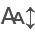

In [85]:
from itables import init_notebook_mode, show

init_notebook_mode(all_interactive=True)

In [86]:
rows = []
for name, (model, history, _, _) in models.items():   #raw results
# for name, (history,config) in models.items():         #saved and loaded results
# for name, (history) in baseline_models.items():       #baselines
    data = {
        'Model': name,
        # 'MSE':history.get('test_mse'),
        'RMSE': history.get('test_rmse'),
        'PCC': history.get('pcc'),
        'CCC': history.get('ccc'),
        
        # 'Acc_Final': history.get('final_acc_rmse'),
        # # Lesort metrics ACC, BWT, FWT
        # 'ACC': history.get('lesort_acc_rmse'),
        # 'BWT': history.get('lesort_bwt_rmse'),
        # 'BWT_norm': history.get('lesort_bwt_rmse_norm'),
        # 'FWT': history.get('lesort_fwt_rmse'),

        'BWT':history.get('lesort_bwt_rmse'),
        # 'bwt_rmse_norm':history.get('lesort_bwt_rmse_norm'),
        # 'bwt_rmse_perdomain':history.get('lesort_bwt_rmse_perdomain'),
        # 'BWT_home': bwt_for_domains(history.get('cl_matrix_rmse'), 0),
        # 'BWT_office': bwt_for_domains(history.get('cl_matrix_rmse'), [1,2,3,4,5]),
        'FWT':history.get('lesort_fwt_rmse'),
        # 'fwt_rmse_perstep':history.get('lesort_fwt_rmse_perstep'),
    }
    # bwt_rmse_perdomain = history.get('lesort_bwt_rmse_perdomain') #average bwt on domain x after trainin on later domains x+1,2,3,4,...
    # for domain, value in zip(config['domains_order'], bwt_rmse_perdomain):
    #     data[f'BWT_{domain}'] = value
    
    # fwt_rmse_perstep = history.get('lesort_fwt_rmse_perstep') #average fwt after training on domain x (on unseen rest of the domains)
    # for i, value in enumerate(fwt_rmse_perstep):
    #     data[f'fwt_after_tr_dom{i}'] = value

    rows.append(data)

df = pd.DataFrame(rows)

#### Individual fold results

In [87]:
df

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


#### Mean results across 5 folds

In [88]:
# For 5 fold cross validation
df_cross = df.copy()
df_cross['Model name'] = df_cross['Model'].str.replace(r'_?fold=\d', '', regex=True)
df_mean = df_cross.groupby('Model name').mean(numeric_only=True)
df_std = df_cross.groupby('Model name').std(numeric_only=True)
df_stats = df_mean.join(df_std, lsuffix='_mean', rsuffix='_std').reset_index()
df_stats


Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


#### Diff: first row model vs rest

In [89]:
metrics = df_stats.columns.drop('Model name')
df_diff = df_stats[metrics].sub(df_stats.loc[0, metrics]).add_suffix('_diff')
diff_df = pd.concat([df_stats, df_diff], axis=1).round(3)
diff_df

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


#### Paired two-sample t-test (dependent folds)

In [101]:
metrics = ["RMSE", "PCC", "CCC"]#, "BWT"]

model1 = list(map(list, zip(*df[
    df["Model"].str.contains(
        "dual_cl_b60"
        , na=False)
][metrics].values.tolist())))

model2 = list(map(list, zip(*df[
    df["Model"].str.contains(
        "single_cl_b60"
        , na=False)
][metrics].values.tolist())))

alpha = 0.05

from scipy.stats import ttest_rel, ttest_ind
for i, m in enumerate(metrics):
    main_mses = model1[i]
    ablated_mses = model2[i]
    result = ttest_rel(main_mses, ablated_mses)
    sig = "SIG" if result.pvalue < alpha else "n.s."
    print(f"{m:4} t = {result.statistic:.3f}, p = {result.pvalue:.3f}, {sig}")

RMSE t = -0.258, p = 0.839, n.s.
PCC  t = 0.406, p = 0.755, n.s.
CCC  t = 0.148, p = 0.906, n.s.


#### Early stopping epochs

In [122]:
# When testing each cl checkpoint (see: TEST_MODE) then inspect early-stop epochs for each domain
# When testing the final model (see: TEST_MODE) then inspect last early-stop epoch

if len(next(iter(models.values()))) == 4:
    for name, (model, history, dataloader, epochs) in models.items():
        if history.get('earlystop_epochs'):
            print(name, history.get('earlystop_epochs'), len(history['train_epoch_loss']))
        else:
            print(f"{name:30}{epochs}")
else:
    for name, (history,config) in models.items():
        if history.get('earlystop_epochs'):
            print(name, history.get('earlystop_epochs'), len(history['train_epoch_loss']))

    

single_cl_b60_fold=1.nomask [4, 1, 0, 0, 0, 2] 13
single_cl_b60_fold=0.nomask [15, 0, 1, 1, 1, 10] 34
dual_cl_b60_fold=1.base [3, 2, 0, 0, 0, 1] 12
dual_cl_b60_fold=0.base [4, 1, 3, 9, 6, 3] 32


### Plots and data statistics

In [359]:
preds, targets = models['dual_cl_b60_fold=0.base'][0]['test_preds_targets']
preds1, _ = models['single_cl_b60_fold=0.nomask'][0]['test_preds_targets']
preds2, _ = models['order_complexdown_fold=0.base'][0]['test_preds_targets']

check_tensor_range(preds)
check_tensor_range(targets)
check_tensor_range(preds1)
check_tensor_range(preds2)

preds = preds * 4 + 1
targets = targets * 4 + 1
preds1 = preds1 * 4 + 1
preds2 = preds2 * 4 + 1



In [319]:
import pandas as pd

tasks = [
    'Vaccum Cleaning', 'Mopping the Floor', 'Carry Warm Food', 
    'Carry Cold Food', 'Carry Drinks', 'Carry Small Objects', 
    'Carry Large Objects', 'Cleaning', 'Starting a conversation'
]

# Assuming you already have the metric lists from get_metrics_per_task
mse_per_task, rmse_per_task, pearson_cc, concord_cc = get_metrics(preds, targets)

# Create a dictionary for the DataFrame
data = {
    'RMSE': rmse_per_task,
    'PCC': pearson_cc,
    'CCC': concord_cc,  
}

# Create DataFrame with tasks as index
df_metrics = pd.DataFrame(data, index=tasks)

df_metrics = df_metrics.round(3)


In [320]:
df_metrics.to_dict()

{'RMSE': {'Vaccum Cleaning': tensor(0.8356),
  'Mopping the Floor': tensor(0.8356),
  'Carry Warm Food': tensor(0.8356),
  'Carry Cold Food': tensor(0.8356),
  'Carry Drinks': tensor(0.8356),
  'Carry Small Objects': tensor(0.8356),
  'Carry Large Objects': tensor(0.8356),
  'Cleaning': tensor(0.8356),
  'Starting a conversation': tensor(0.8356)},
 'PCC': {'Vaccum Cleaning': tensor(0.5546),
  'Mopping the Floor': tensor(0.5546),
  'Carry Warm Food': tensor(0.5546),
  'Carry Cold Food': tensor(0.5546),
  'Carry Drinks': tensor(0.5546),
  'Carry Small Objects': tensor(0.5546),
  'Carry Large Objects': tensor(0.5546),
  'Cleaning': tensor(0.5546),
  'Starting a conversation': tensor(0.5546)},
 'CCC': {'Vaccum Cleaning': tensor(0.3637),
  'Mopping the Floor': tensor(0.3637),
  'Carry Warm Food': tensor(0.3637),
  'Carry Cold Food': tensor(0.3637),
  'Carry Drinks': tensor(0.3637),
  'Carry Small Objects': tensor(0.3637),
  'Carry Large Objects': tensor(0.3637),
  'Cleaning': tensor(0.3637)

#### Plots

In [326]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Helper to create DataFrame with scaled preds and targets and add model name
def create_df(preds, targets, task_names, model_name):
    
    pred_flat = preds.flatten()
    target_flat = targets.flatten()
    tasks = np.tile(task_names, preds.shape[0])

    df = pd.DataFrame({
        'Predicted': pred_flat,
        'Target': target_flat,
        'Task': tasks,
        'Model': model_name
    })
    return df

task_names = [
    'Vaccum Cleaning', 'Mopping the Floor', 'Carry Warm Food',
    'Carry Cold Food', 'Carry Drinks', 'Carry Small Objects',
    'Carry Large Objects', 'Cleaning', 'Starting a conversation'
]

group1 = ['Carry Warm Food', 'Carry Cold Food', 'Carry Drinks', 'Starting a conversation']
group2 = ['Vaccum Cleaning', 'Mopping the Floor', 'Carry Large Objects', 'Carry Small Objects', 'Cleaning']

# Create DataFrames for the two models
df_nocl = create_df(preds1,
                   targets,
                   task_names,
                   'Offline DualBranch')

df_base = create_df(preds,
                   targets,
                   task_names,
                   'EDDualBranch')

# Add group labels
def assign_group(task):
    if task in group1:
        return 'Group 1'
    elif task in group2:
        return 'Group 2'
    else:
        return 'Other'

df_nocl['Group'] = df_nocl['Task'].apply(assign_group)
df_base['Group'] = df_base['Task'].apply(assign_group)

# Filter to groups separately and concatenate Offline DualBranch and DualBranch for each group
df_clustered = pd.concat([df_nocl[df_nocl['Group'] == 'Group 1'],
                          df_base[df_base['Group'] == 'Group 1']])

df_spread = pd.concat([df_nocl[df_nocl['Group'] == 'Group 2'],
                       df_base[df_base['Group'] == 'Group 2']])

# Create 1 row, 2 col subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=('Group 1', 'Group 2'))

# Colors for models
color_map = {'Offline DualBranch': 'green', 'EDDualBranch': 'blue'}

# Plot Clustered Group: two datasets colored by model
# for model_name, color in color_map.items():
for model_name, color, opacity in [('EDDualBranch', color_map['EDDualBranch'], 0.6), ('Offline DualBranch', color_map['Offline DualBranch'], 0.3)]:
    df_plot = df_clustered[df_clustered['Model'] == model_name]
    fig.add_trace(
        go.Scatter(
            x=df_plot['Target'], y=df_plot['Predicted'],
            mode='markers',
            marker=dict(color=color, size=7, opacity=opacity),
            name=model_name,
            showlegend=True if model_name == 'Offline DualBranch' else False  # show once
        ),
        row=1, col=1
    )

# Plot Spread Group: two datasets colored by model
# for model_name, color in color_map.items():
for model_name, color, opacity in [('Offline DualBranch', color_map['Offline DualBranch'], 0.4), ('EDDualBranch', color_map['EDDualBranch'], 0.4)]:
    df_plot = df_spread[df_spread['Model'] == model_name]
    fig.add_trace(
        go.Scatter(
            x=df_plot['Target'], y=df_plot['Predicted'],
            mode='markers',
            marker=dict(color=color, size=7, opacity=opacity),
            name=model_name,
            showlegend=True if model_name == 'EDDualBranch' else False
        ),
        row=1, col=2
    )

# Remove 'title' from axis_kwargs!
axis_kwargs = dict(range=[0.8, 5.2], dtick=0.5)

# After adding all traces, set axis titles explicitly
fig.update_xaxes(title_text='Target Score', row=1, col=1, **axis_kwargs)
fig.update_yaxes(title_text='Predicted Score', row=1, col=1, **axis_kwargs)
fig.update_xaxes(title_text='Target Score', row=1, col=2, **axis_kwargs)
fig.update_yaxes(title_text='Predicted Score', row=1, col=2, **axis_kwargs)

fig.update_layout(
    template='plotly',
    width=1200,
    height=600,
    title='Predicted vs Target Scores<br>by Group and Model',
    title_x=0.5,
    legend_title_text='Model',
)

fig.show()



In [332]:
len(pred_flat)

3600

In [333]:
import numpy as np
import plotly.express as px
import pandas as pd

# Example input arrays: predicted and target values (shape: 240 samples x 9 tasks)
# predicted = np.random.rand(240, 9)
# target = np.random.rand(240, 9)


# Your task names in order
task_names = [
    'Vaccum Cleaning', 'Mopping the Floor', 'Carry Warm Food',
    'Carry Cold Food', 'Carry Drinks', 'Carry Small Objects',
    'Carry Large Objects', 'Cleaning', 'Starting a conversation'
]

# Flatten predictions and targets
pred_flat = preds.flatten()
target_flat = targets.flatten()
assert len(pred_flat) == len(target_flat)
# Create task labels for each point using task names (repeat 240 times for each task)
tasks = np.tile(task_names, len(pred_flat)//9)  # This creates an array of task names (length 9*240=2160)

# Create DataFrame with actual task names
df = pd.DataFrame({
    'Predicted': pred_flat,
    'Target': target_flat,
    'Task': tasks  # Task names as strings
})

# # Define your task groups and colors
# group1 = ['Carry Warm Food', 'Carry Cold Food', 'Carry Drinks', 'Starting a conversation']
# group2 = ['Vaccum Cleaning', 'Mopping the Floor', 'Carry Large Objects', 'Carry Small Objects', 'Cleaning', ]

# color_group1 = 'blue'
# color_group2 = 'orange'

# # Create mapping from task name to color
# color_map = {task: color_group1 for task in group1}
# color_map.update({task: color_group2 for task in group2})

fig = px.scatter(df, x='Target', y='Predicted', color='Task',
                 title='Predicted vs Target Values',
                 labels={'Target': 'True Value', 'Predicted': 'Predicted Value'},
                 width=700,
                 height=600,
                #  color_discrete_map=color_map
                 color_discrete_sequence=px.colors.qualitative.Safe
                 )

fig.update_layout(template='plotly', title_x=0.5, yaxis=dict(range=[0, 5.2], dtick=0.5), xaxis=dict(range=[0, 5.2], dtick=0.5),)
fig.update_traces(marker=dict(size=7, opacity=0.5))
fig.show()
#predstargets_scatter


In [334]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px

# Select different palettes for your groups
palette_group1 = px.colors.qualitative.Bold
palette_group2 = px.colors.qualitative.Set3


colors_group1 = palette_group1[:len(group1)]
colors_group2 = palette_group2[:len(group2)]

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Clustered Tasks", "Spread Tasks"))

# Add group1 tasks with palette_group1 colors
for task, color in zip(group1, colors_group1):
    df_task = df[df['Task'] == task]
    fig.add_trace(
        go.Scatter(x=df_task['Target'], y=df_task['Predicted'], mode='markers',
                   marker=dict(color=color, size=7, opacity=0.5),
                   name=task),
        row=1, col=1
    )

# Add group2 tasks with palette_group2 colors
for task, color in zip(group2, colors_group2):
    df_task = df[df['Task'] == task]
    fig.add_trace(
        go.Scatter(x=df_task['Target'], y=df_task['Predicted'], mode='markers',
                   marker=dict(color=color, size=7, opacity=0.5),
                   name=task),
        row=1, col=2
    )

fig.update_layout(
    template='plotly_white',
    width=1100, height=500,
    xaxis=dict(range=[0.8, 5.2], dtick=0.5),
    yaxis=dict(range=[0.8, 5.2], dtick=0.5),
    xaxis2=dict(range=[0.8, 5.2], dtick=0.5),
    yaxis2=dict(range=[0.8, 5.2], dtick=0.5),
    title="Predicted vs Target Values by Task Groups",
    legend_title_text='Task',
)

fig.show()


In [335]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Create subplots
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Group 1 Tasks", "Group 2 Tasks"))

# Add traces for group1 tasks
for task in group1:
    df_task = df[df['Task'] == task]
    fig.add_trace(
        go.Scatter(x=df_task['Target'], y=df_task['Predicted'], mode='markers',
                   marker=dict(color='purple', size=7, opacity=0.5),
                   name=task),
        row=1, col=1
    )

# Add traces for group2 tasks
for task in group2:
    df_task = df[df['Task'] == task]
    fig.add_trace(
        go.Scatter(x=df_task['Target'], y=df_task['Predicted'], mode='markers',
                   marker=dict(color='orange', size=7, opacity=0.5),
                   name=task),
        row=1, col=2
    )

fig.update_xaxes(title_text='Target Score', row=1, col=1, **axis_kwargs)
fig.update_yaxes(title_text='Predicted Score', row=1, col=1, **axis_kwargs)
fig.update_xaxes(title_text='Target Score', row=1, col=2, **axis_kwargs)
fig.update_yaxes(title_text='Predicted Score', row=1, col=2, **axis_kwargs)

# Layout
fig.update_layout(
    template='plotly',
    width=1200, height=600,
    xaxis=dict(range=[0, 5.2], dtick=0.5),
    yaxis=dict(range=[0, 5.2], dtick=0.5),
    xaxis2=dict(range=[0, 5.2], dtick=0.5),
    yaxis2=dict(range=[0, 5.2], dtick=0.5),
    title="EDDualBranch<br>Predicted vs Target Scores by Task Groups",
    title_x=0.5,
    legend_title_text='Task',
)

fig.show()


In [364]:
import torch
import torch.nn as nn

preds, targets = preds,targets
preds = torch.tensor(preds, dtype=torch.float32)
targets = torch.tensor(targets, dtype=torch.float32)

# Compute element-wise squared errors
mse = nn.MSELoss(reduction='none')(preds, targets)  # shape [n_images, 9]

# Compute element-wise RMSE in original scale
rmse_per_element = torch.sqrt(mse)

# Maximum RMSE across all predictions (max error)
max_rmse = rmse_per_element.max().item()

# Overall RMSE (mean squared error -> root -> rescale)
final_rmse = torch.sqrt(mse.mean())

print(f"Max RMSE per element: {max_rmse:.3f}, min {rmse_per_element.min().item():.6f}, median {rmse_per_element.median().item():.3f}")
print(f"Overall RMSE: {final_rmse:.4f}")


Max RMSE per element: 2.879, min 0.000721, median 0.577
Overall RMSE: 0.8356


C:\Users\rrkar\AppData\Local\Temp\ipykernel_10896\3749409908.py:5: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).

C:\Users\rrkar\AppData\Local\Temp\ipykernel_10896\3749409908.py:6: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



In [337]:
rmse_per_task = torch.sqrt(mse.mean(dim=0))
rmse_per_task = rmse_per_task.flatten().cpu().numpy()
task_names = ['Vaccum Cleaning', 'Mopping the Floor', 'Carry Warm Food',
              'Carry Cold Food', 'Carry Drinks', 'Carry Small Objects',
              'Carry Large Objects', 'Cleaning', 'Starting a conversation']

# Create a long-format DataFrame for plotting
data = {
    'RMSE': rmse_per_task,
    'Task': task_names
}
df_tasks = pd.DataFrame(data)

In [338]:
rmse_per_sample = torch.sqrt(mse.mean(dim=1))
rmse_per_sample.shape

torch.Size([400])

In [339]:
worst_samples = torch.topk(rmse_per_sample, k=10)  
worst_samples

torch.return_types.topk(
values=tensor([1.9461, 1.8094, 1.7607, 1.7250, 1.7234, 1.7163, 1.6429, 1.5846, 1.5560,
        1.5543]),
indices=tensor([308,  79, 157, 162, 173, 243, 176, 144, 200, 224]))

In [340]:
targets[72]

tensor([2.5000, 2.5000, 3.5000, 3.7500, 3.7500, 3.7500, 2.2500, 3.7500, 3.5000])

In [341]:
preds[72]

tensor([2.4587, 2.3523, 3.2118, 3.3237, 3.5698, 3.5907, 2.2056, 3.5526, 3.5902])

In [342]:
torch.set_printoptions(precision=3, sci_mode=False)
rmse_per_element[[186, 150,   1,  22,   2,   0]]

tensor([[0.792, 0.864, 0.385, 0.233, 0.037, 1.137, 0.130, 0.275, 1.305],
        [0.814, 1.025, 0.288, 0.118, 0.214, 0.298, 0.878, 1.107, 0.017],
        [0.553, 0.643, 0.878, 0.928, 0.743, 0.681, 1.202, 0.816, 0.414],
        [0.307, 0.434, 1.415, 1.515, 1.665, 0.666, 0.570, 0.844, 0.202],
        [0.504, 0.431, 0.193, 0.021, 0.261, 0.384, 0.405, 0.086, 0.790],
        [0.605, 0.665, 0.790, 0.547, 0.354, 0.974, 0.970, 1.666, 1.177]])

In [343]:
preds_per_sample = preds.mean(dim=1)

In [344]:
x = torch.sqrt(nn.MSELoss(reduction='none')(preds1, targets))
torch.topk(x, 10, dim=0, largest=False)

torch.return_types.topk(
values=tensor([[0.000, 0.003, 0.004, 0.001, 0.002, 0.003, 0.004, 0.002, 0.001],
        [0.005, 0.007, 0.007, 0.002, 0.006, 0.004, 0.005, 0.003, 0.002],
        [0.011, 0.010, 0.007, 0.002, 0.007, 0.008, 0.007, 0.009, 0.004],
        [0.015, 0.011, 0.008, 0.005, 0.010, 0.012, 0.007, 0.010, 0.007],
        [0.019, 0.015, 0.012, 0.006, 0.010, 0.014, 0.008, 0.023, 0.012],
        [0.028, 0.018, 0.020, 0.009, 0.010, 0.015, 0.009, 0.027, 0.013],
        [0.028, 0.018, 0.026, 0.013, 0.014, 0.021, 0.009, 0.029, 0.014],
        [0.029, 0.025, 0.029, 0.014, 0.015, 0.022, 0.015, 0.030, 0.015],
        [0.038, 0.029, 0.032, 0.021, 0.018, 0.024, 0.017, 0.037, 0.019],
        [0.038, 0.033, 0.033, 0.029, 0.019, 0.026, 0.018, 0.040, 0.020]]),
indices=tensor([[ 33,  49, 232, 365,  49,  28, 335, 368,  13],
        [380, 334, 192, 179, 312, 307, 346, 241, 363],
        [ 85, 194, 394, 228, 317, 399, 366, 229, 118],
        [347, 204,  46, 235, 300, 253, 163, 384,  45],
        

In [345]:
torch.topk(rmse_per_sample, 10)

torch.return_types.topk(
values=tensor([1.946, 1.809, 1.761, 1.725, 1.723, 1.716, 1.643, 1.585, 1.556, 1.554]),
indices=tensor([308,  79, 157, 162, 173, 243, 176, 144, 200, 224]))

In [346]:
mask = (preds < 0.375) | (preds > 0.625)
rmse_per_element[~mask] = -float('inf')

torch.topk(rmse_per_element, 10, dim=0)

torch.return_types.topk(
values=tensor([[2.586, 2.382, 2.498, 2.472, 2.553, 2.027, 2.370, 2.879, 2.341],
        [2.514, 2.293, 2.370, 2.386, 2.494, 1.920, 2.289, 2.255, 2.203],
        [2.413, 2.220, 2.253, 2.334, 2.469, 1.916, 2.205, 2.153, 2.201],
        [2.278, 2.157, 2.218, 2.295, 2.121, 1.855, 2.106, 2.078, 2.190],
        [2.233, 2.095, 2.157, 2.231, 2.109, 1.819, 2.076, 2.003, 2.156],
        [2.211, 2.079, 2.058, 2.185, 2.035, 1.815, 2.074, 1.903, 2.155],
        [2.007, 2.061, 1.962, 2.164, 2.024, 1.812, 2.061, 1.778, 1.983],
        [1.980, 1.943, 1.886, 2.064, 2.004, 1.810, 2.018, 1.776, 1.973],
        [1.909, 1.937, 1.866, 2.048, 1.988, 1.792, 1.887, 1.743, 1.973],
        [1.848, 1.934, 1.863, 1.909, 1.944, 1.751, 1.772, 1.731, 1.964]]),
indices=tensor([[308, 144, 162, 162, 162, 157, 243, 157, 362],
        [144, 308, 200, 176, 176,  79, 215, 192,  51],
        [224, 224,  79,  79,  79, 105, 377, 122,  75],
        [370, 287, 176, 209, 392, 303, 259, 305, 346],
        

In [347]:
preds_per_sample[[186, 150,   1,  22,   2,   0, 154,  36,  33, 120]]*4+1

tensor([12.210, 14.433, 12.394, 14.838, 12.666, 11.639, 12.261, 13.682, 10.805,
        11.192])

In [348]:
targets_per_sample = targets.mean(dim=1)

In [349]:
rmse_per_element = rmse_per_element.flatten().cpu().numpy()
preds_per_element = preds.flatten().cpu().numpy()
targets_per_element = targets.flatten().cpu().numpy()

In [350]:
import plotly.express as px

# Convert tensors to numpy arrays if necessary
rmse_np = rmse_per_sample.cpu().numpy()
preds_np = preds_per_sample.cpu().numpy() 
targets_np = targets_per_sample.cpu().numpy() 

rmse_np = rmse_per_element
preds_np = preds_per_element
targets_np = targets_per_element

fig = go.Figure()

# Trace for RMSE vs Predictions
fig.add_trace(go.Scatter(
    x=preds_np,
    y=rmse_np,
    mode='markers',
    name='RMSE vs Predictions',
    marker=dict(color='blue')
))

# Trace for RMSE vs Targets
fig.add_trace(go.Scatter(
    x=targets_np,
    y=rmse_np,
    mode='markers',
    name='RMSE vs Targets',
    marker=dict(color='red')
))

fig.update_layout(
    title='RMSE vs Predictions and Targets',
    xaxis_title='Predictions / Targets',
    yaxis_title='RMSE',
    legend_title='Legend',
    template='plotly_white',
    width = 700,
    height = 600,
)

fig.show()


In [360]:
import numpy as np
from scipy.stats import gaussian_kde
import plotly.graph_objects as go

# --- REPLACE THESE WITH YOUR ACTUAL DATA ---
lgr_preds = preds
dualbranch_preds = preds1
targets = targets
perplexity_preds = preds2

# lgr_preds_np = lgr_preds.numpy().flatten()
# dualbranch_preds_np = dualbranch_preds.numpy().flatten()
# targets_np = targets.numpy().flatten()
# perplexity_preds_np = perplexity_preds.numpy().flatten()
lgr_preds_np = preds.numpy().flatten()
dualbranch_preds_np = preds1.numpy().flatten()
targets_np = targets.numpy().flatten()
perplexity_preds_np = preds2.numpy().flatten()
# --- REPLACE ENDS ---

# Determine common x range (don't go outside data bounds)
xmin = min(lgr_preds_np.min(), dualbranch_preds_np.min(), targets_np.min())
xmax = max(lgr_preds_np.max(), dualbranch_preds_np.max(), targets_np.max())
lgr_x_kde = np.linspace(lgr_preds_np.min(), lgr_preds_np.max(), 200)
dualbranch_x_kde = np.linspace(dualbranch_preds_np.min(), dualbranch_preds_np.max(), 200)
target_x_kde = np.linspace(targets_np.min(), targets_np.max(), 200)

# Calculate KDEs
kde_lgr = gaussian_kde(lgr_preds_np)
kde_dualbranch = gaussian_kde(dualbranch_preds_np)
kde_targets = gaussian_kde(targets_np)
kde_lgr_vals = kde_lgr(lgr_x_kde)
kde_dualbranch_vals = kde_dualbranch(dualbranch_x_kde)
kde_targets_vals = kde_targets(target_x_kde)

# Calculate normalized histogram
hist_perplexity, bin_edges = np.histogram(perplexity_preds_np, bins=np.arange(0,7)-0.5, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2



# Colors with transparency (alpha); here alpha=0.5 (can adjust)
color_lgr = 'rgba(255, 165, 0, 0.3)'  
color_dualbranch =  'rgba(0, 0, 255, 0.5)'
color_targets = 'rgba(255, 0, 0, 0.3)' 

fig = go.Figure()

# Add filled, opaque KDE lines
fig.add_trace(go.Scatter(
    x=lgr_x_kde, y=kde_lgr_vals, 
    fill='tozeroy', fillcolor=color_lgr,
    mode='lines', name='FedLGR KDE',
    line=dict(color='orange', width=1.5)
))

fig.add_trace(go.Scatter(
    x=target_x_kde, y=kde_targets_vals, 
    fill='tozeroy', fillcolor=color_targets,
    mode='lines', name='Targets KDE',
    line=dict(color='red', width=1.5)
))
fig.add_trace(go.Scatter(
    x=dualbranch_x_kde, y=kde_dualbranch_vals, 
    fill='tozeroy', fillcolor=color_dualbranch,
    mode='lines', name='EDDualBranch KDE',
    line=dict(color='blue', width=1.5)
))

# Add histogram bars
fig.add_trace(go.Bar(
    x=bin_centers, y=hist_perplexity, name='Sonar-Pro Histogram',
    opacity=0.6, marker_color='green'
))

fig.update_layout(
    template='plotly',
    width=1200, height=600,
    xaxis=dict(range=[0, 5.5], dtick=0.5),
    # yaxis=dict(range=[0, 1.1]),
    barmode='overlay',
    title='Distribution of Predictions',
    xaxis_title='Predicted Score',
    yaxis_title='Density',
    legend_title='Model',
    title_x=0.5,
)

fig.show()

In [361]:
import plotly.express as px
lgr_preds_np = lgr_preds.numpy().flatten()
dualbranch_preds_np = dualbranch_preds.numpy().flatten()
targets_np = targets.numpy().flatten()
perplexity_preds_np = perplexity_preds.numpy().flatten()
def _rmse(preds, targets):
    return np.sqrt((preds - targets)**2)
lgr_preds_rmse_np = _rmse(lgr_preds_np, targets_np)
dualbranch_preds_rmse_np = _rmse(dualbranch_preds_np, targets_np)
perplexity_preds_rmse_np = _rmse(perplexity_preds_np, targets_np)
# Scatter plot of targets vs predictions colored by RMSE
fig = px.scatter(x=targets_np, y=perplexity_preds_np,
                 color=perplexity_preds_rmse_np,
                 labels={'x': 'Target Score', 'y': 'Predicted Score', 'color': 'RMSE'},
                 title='Sonar-Pro<br>Predicted vs Target Scores',
                 color_continuous_scale='Bluered',
                 )
fig.update_layout(
    xaxis=dict(range=[0, 5.2], dtick=0.5),
    yaxis=dict(range=[0, 5.2], dtick=0.5),
    width = 700,
    height = 650,
    template='plotly',
    title_x=0.5,
)
fig.update_traces(marker=dict(size=10, opacity=0.8))
fig.show()


#### Plots - RMSE stats

In [367]:
rmse_per_element
worst_samples_per_task = torch.topk(rmse_per_element, k=1, dim=0)  
vals, idxs = torch.topk(rmse_per_element, k=3, dim=0)
worst_samples_per_task


torch.return_types.topk(
values=tensor([[2.443, 2.477, 2.339, 2.326, 2.222, 2.519, 2.975, 2.641, 2.432]]),
indices=tensor([[105,  87,  99, 199,  40, 122, 376, 122,  41]]))

In [372]:
import plotly.express as px
import pandas as pd

rmse_per_element = torch.sqrt(nn.MSELoss(reduction='none')(preds1, targets))
rmse_all = rmse_per_element.flatten().cpu().numpy()
df_all = pd.DataFrame({'RMSE': rmse_all})

fig = px.histogram(df_all, x='RMSE',
                   nbins=30,
                   title='Distribution of RMSE Values',
                   labels={'RMSE': 'RMSE','count': 'Sample count'})

# Calculate quantiles including 25th, 50th, 75th, 90th and 99th
quantile_values = df_all['RMSE'].quantile([0.25, 0.5, 0.75, 0.9, 0.99])

for q, val in quantile_values.items():
    fig.add_vline(
        x=val,
        line_dash='dash',
        line_color='red' if q >= 0.9 else 'blue',
        annotation_text=f"P{int(q*100)}",
        annotation_position="top left"
    )

# Update layout to show vertical grid lines and set more frequent ticks
fig.update_layout(
    template='plotly',
    height=500,
    width=1000,
    xaxis=dict(
        dtick=0.1,  # set interval between ticks (adjust as needed)
        tick0=0,
        ticks="outside",
        range=[0, 5]
        
    ),
    title_x=0.5,
    yaxis=dict(showgrid=True),
    yaxis_title='Sample count',
    # xaxis=dict(range=[0.8, 3.0], dtick=0.5),
)

fig.show()


In [370]:
import torch
import pandas as pd
import plotly.express as px

# Your RMSE tensor (example shape: [n_samples, 9])
# rmse_per_element = torch.sqrt(mse) * 4  # given

# Convert to numpy
rmse_np = rmse_per_element#.cpu().numpy()  # shape (n_samples, 9)

# Task names
task_names = ['Vaccum Cleaning', 'Mopping the Floor', 'Carry Warm Food',
              'Carry Cold Food', 'Carry Drinks', 'Carry Small Objects',
              'Carry Large Objects', 'Cleaning', 'Starting a conversation']

# Create a long-format DataFrame for plotting
data = {
    'RMSE': rmse_np.flatten(),
    'Task': [task for task in task_names for _ in range(rmse_np.shape[0])]
}
df = pd.DataFrame(data)

# Create box plot showing distribution and quantiles
fig = px.box(df, x='Task', y='RMSE',
             title='RMSE Distribution per Task with Quantiles',
             labels={'RMSE': 'RMSE', 'Task': 'Task'},
             points='all')  # 'all' to show all data points

fig.add_scatter(x=df_tasks['Task'], y=df_tasks['RMSE'],
                mode='markers',
                marker=dict(color='red', symbol='diamond', size=10),
                name='Mean RMSE')

fig.update_layout(xaxis_tickangle=-45, template='plotly_white', height=600, width=900)
fig.show()


In [371]:
rmse_per_element = torch.sqrt(nn.MSELoss(reduction='none')(preds1, targets))
rmse_flat = rmse_per_element.flatten()

import plotly.graph_objects as go
import numpy as np

# Convert rmse_flat tensor to numpy array
rmse_np = rmse_flat.cpu().numpy()

# Calculate percentiles (already done by you, for completeness)
# percentiles = np.array([0.5, 0.75, 0.90, 0.95, 0.99])
# percentile_values = np.quantile(rmse_np, percentiles)
# for p, val in zip(percentiles, percentile_values):
#     print(f"{int(p.item()*100)}th percentile: {val.item():.3f}")

thresholds = [0.5, 0.75, 1.0, 2.0]
total = rmse_flat.numel()
for t in thresholds:
    percent = (rmse_flat <= t).sum().item() / total * 100
    print(f"RMSE < {t}: {percent:.1f}% of predictions")



RMSE < 0.5: 43.8% of predictions
RMSE < 0.75: 63.6% of predictions
RMSE < 1.0: 77.2% of predictions
RMSE < 2.0: 98.9% of predictions


In [373]:
import numpy as np

def empirical_cdf(data):
    sorted_data = np.sort(data)
    yvals = np.arange(1, len(sorted_data) + 1) / len(sorted_data) * 100
    return sorted_data, yvals

lgr_x, lgr_y = empirical_cdf(lgr_preds_rmse_np)
dualbranch_x, dualbranch_y = empirical_cdf(dualbranch_preds_rmse_np)
perplexity_x, perplexity_y = empirical_cdf(perplexity_preds_rmse_np)

import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=dualbranch_x, y=dualbranch_y, mode='lines', name='EDDualBranch', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=lgr_x, y=lgr_y, mode='lines', name='FedLGR', line=dict(color='orange')))

fig.add_trace(go.Scatter(x=perplexity_x, y=perplexity_y, mode='lines', name='Sonar-Pro', line=dict(color='green')))

fig.update_layout(
    title='Empirical Cumulative Distribution of RMSEs',
    xaxis_title='RMSE Value',
    yaxis_title='Cumulative Percentage of Predictions (%)',
    hovermode='closest',
    legend_title='Model',
    xaxis=dict(range=[0, 4.0], dtick=0.5),
    yaxis=dict(range=[0, 109], dtick=10),
    height=500,
    width=700,
    template='plotly',
    title_x=0.5,
)

# Add vertical threshold lines at 0.5, 1, and 2 RMSE
thresholds = [0.5, 1, 2]
for threshold in thresholds:
    fig.add_shape(
        type="line", x0=threshold, x1=threshold, y0=0, y1=200,
        line=dict(color="black", dash="dot", width=2),
    )


fig.show()

In [374]:
import numpy as np
import plotly.graph_objects as go

# Replace these with your actual numpy arrays
lgr_preds_np = lgr_preds.numpy().flatten()
dualbranch_preds_np = dualbranch_preds.numpy().flatten()
perplexity_preds_np = perplexity_preds.numpy().flatten()
targets_np = targets.numpy().flatten()

def _rmse(preds, targets):
    return np.sqrt((preds - targets)**2)
# Calculate absolute errors (element-wise)
abs_errors = [
    _rmse(dualbranch_preds_np, targets_np),
    _rmse(lgr_preds_np, targets_np),
    _rmse(perplexity_preds_np, targets_np)
]
labels = ['EDDualBranch','FedLGR', 'Sonar-Pro']
colors = ['blue','orange','green']

fig = go.Figure()
annotations = []

for i, (label, arr, color) in enumerate(zip(labels, abs_errors, colors)):
    # Add boxplot
    fig.add_trace(go.Box(
        y=arr,
        name=label,
        marker_color=color,
        # boxmean='sd',  # Show mean and SD
        # boxpoints='all',  # Show all points
        # jitter=0.5,  # Jitter points horizontally
        # pointpos=0.0  # Center points on x-axis
    ))
    # Calculate statistics for this model
    median = np.median(arr)
    minimum = np.min(arr)
    maximum = np.max(arr)
    q1 = np.quantile(arr, 0.25)
    q3 = np.quantile(arr, 0.75)
    annotations.append(dict(x=i, y=median, text=f"Median: {median:.3f}", showarrow=True, ax=-100, ay=0))       # To the left of median
    annotations.append(dict(x=i, y=minimum, text=f"Min: {minimum:.3f}", showarrow=True, ax=-100, ay=0))     # Below min
    annotations.append(dict(x=i, y=maximum, text=f"Max: {maximum:.3f}", showarrow=True, ax=-100, ay=0))      # Below max
    annotations.append(dict(x=i, y=q1, text=f"Q1: {q1:.3f}", showarrow=True, ax=-100, ay=0))                 # Above Q1
    annotations.append(dict(x=i, y=q3, text=f"Q3: {q3:.3f}", showarrow=True, ax=-100, ay=0))  

# Final layout
fig.update_layout(
    template='plotly',
    width=900, height=700,
    xaxis_title='Model',
    yaxis_title='RMSE values',
    legend_title_text='Model',
    title='Distribution of RMSEs',
    annotations=annotations,
    title_x=0.5,
    yaxis=dict(range=[-0.4, 4.4], dtick=0.2),

)

fig.show()


In [384]:
import numpy as np
from scipy.stats import gaussian_kde
import plotly.graph_objects as go



def _rmse(preds, targets):
    return np.sqrt((preds - targets)**2)

lgr_preds_np = lgr_preds.numpy().flatten()
dualbranch_preds_np = dualbranch_preds.numpy().flatten()
targets_np = targets.numpy().flatten()
perplexity_preds_np = perplexity_preds.numpy().flatten()

lgr_preds_np = _rmse(lgr_preds_np, targets_np)
dualbranch_preds_np = _rmse(dualbranch_preds_np, targets_np)
perplexity_preds_np = _rmse(perplexity_preds_np, targets_np)
# --- REPLACE ENDS ---

lgr_x_kde = np.linspace(lgr_preds_np.min(), lgr_preds_np.max(), 200)
dualbranch_x_kde = np.linspace(dualbranch_preds_np.min(), dualbranch_preds_np.max(), 200)
perplexity_x_kde = np.linspace(perplexity_preds_np.min(), perplexity_preds_np.max(), 200)

# Calculate KDEs
kde_lgr = gaussian_kde(lgr_preds_np)
kde_dualbranch = gaussian_kde(dualbranch_preds_np)
kde_perplexity = gaussian_kde(perplexity_preds_np)
kde_lgr_vals = kde_lgr(lgr_x_kde)
kde_dualbranch_vals = kde_dualbranch(dualbranch_x_kde)
kde_perplexity_vals = kde_perplexity(perplexity_x_kde)



# Colors with transparency (alpha); here alpha=0.5 (can adjust)
color_lgr = 'rgba(255, 165, 0, 0.3)'  
color_dualbranch =  'rgba(0, 0, 255, 0.5)'
color_perplexity = 'rgba(0, 255, 0, 0.3)' 

fig = go.Figure()

# Add filled, opaque KDE lines
fig.add_trace(go.Scatter(
    x=lgr_x_kde, y=kde_lgr_vals, 
    fill='tozeroy', fillcolor=color_lgr,
    mode='lines', name='LGR KDE',
    line=dict(color='orange', width=1.5)
))

fig.add_trace(go.Scatter(
    x=perplexity_x_kde, y=kde_perplexity_vals, 
    fill='tozeroy', fillcolor=color_perplexity,
    mode='lines', name='Sonar-Pro KDE',
    line=dict(color='green', width=1.5)
))
fig.add_trace(go.Scatter(
    x=dualbranch_x_kde, y=kde_dualbranch_vals, 
    fill='tozeroy', fillcolor=color_dualbranch,
    mode='lines', name='DualBranch KDE',
    line=dict(color='blue', width=1.5)
))

tot_max = max(lgr_preds_np.max(), dualbranch_preds_np.max(), perplexity_preds_np.max())
fig.update_layout(
    template='plotly',
    width=1200, height=600,
    xaxis=dict(range=[0, tot_max+1], dtick=0.5),
    yaxis=dict(range=[0, 1.1]),
    barmode='overlay',
    title='Distribution of RMSEs',
    xaxis_title='RMSE',
    yaxis_title='Normalised Density',
    legend_title='Model',
    title_x=0.5,
)

fig.show()

In [385]:
import numpy as np
def get_top_bottom_acc(pred,targ):
    # Find the task with the highest score for each sample
    highest_target = np.argmax(targ, axis=1)
    highest_pred = np.argmax(pred, axis=1)
    top_accuracy = np.mean(highest_target == highest_pred)

    # Find the task with the lowest score for each sample
    lowest_target = np.argmin(targ, axis=1)
    lowest_pred = np.argmin(pred, axis=1)
    bottom_accuracy = np.mean(lowest_target == lowest_pred)
    return top_accuracy, bottom_accuracy

In [386]:
pred = dualbranch_preds.numpy()
targ = targets.numpy()
get_top_bottom_acc(pred, targ)


(np.float64(0.245), np.float64(0.2625))

In [387]:
group1_indices = [2, 3, 4, 8]  # tasks 3,4,5,9
group2_indices = [i for i in range(9) if i not in group1_indices]

print(get_top_bottom_acc(pred[:, group1_indices], targ[:, group1_indices]))
print(get_top_bottom_acc(pred[:, group2_indices], targ[:, group2_indices]))

(np.float64(0.1775), np.float64(0.5225))
(np.float64(0.5025), np.float64(0.3375))


In [388]:
group1_indices = [2, 3, 4]  # tasks 3,4,5,9
group2_indices = [i for i in range(8) if i not in group1_indices]
print(get_top_bottom_acc(pred[:, :-1], targ[:, :-1]))
print(get_top_bottom_acc(pred[:, :-1][:, group1_indices], targ[:, :-1][:, group1_indices]))
print(get_top_bottom_acc(pred[:, :-1][:, group2_indices], targ[:, :-1][:, group2_indices]))

(np.float64(0.2875), np.float64(0.2625))
(np.float64(0.1925), np.float64(0.8525))
(np.float64(0.5025), np.float64(0.3375))


### Statistical tests

In [93]:
import numpy as np
import torch
from corrstats import dependent_corr
from tqdm import tqdm

# --- RMSE calculation across all samples and tasks ---
def rmse_fn(preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    mse_loss = nn.MSELoss()
    mse = mse_loss(preds, targets)
    return torch.sqrt(mse)

# --- Fisher z transform pooling of 9 per-task values ---
def pooled_fisher_z(values: torch.Tensor) -> torch.Tensor:
    z = torch.atanh(values)
    mean_z = z.mean()
    return torch.tanh(mean_z)

# --- Compute pooled metric (PCC or CCC) over tasks ---
def compute_pooled_metric(metric_fn, preds, targets) -> torch.Tensor:
    results = []
    for i in range(preds.shape[1]):
        # metric_fn expects shape (N,), single task column
        val = metric_fn(preds[:, i], targets[:, i])
        results.append(val)
    results = torch.stack(results)
    pooled = pooled_fisher_z(results)
    return pooled

# --- RMSE-specific bootstrap CI difference ---
def bootstrap_ci_diff_rmse(preds1, preds2, targets,
                           n_boot=1000, device='cuda'):
    preds1 = preds1.to(device)
    preds2 = preds2.to(device)
    targets = targets.to(device)
    n = preds1.shape[0]
    diffs = []
    for _ in tqdm(range(n_boot), leave=False):
        idx = torch.randint(0, n, (n,), device=device)
        rmse1 = rmse_fn(preds1[idx], targets[idx])
        rmse2 = rmse_fn(preds2[idx], targets[idx])
        diffs.append((rmse1 - rmse2).cpu().item())
    ci_lower = np.percentile(diffs, 2.5)
    ci_upper = np.percentile(diffs, 97.5)
    return ci_lower.item(), ci_upper.item()

# --- RMSE-specific permutation test ---
def permutation_test_diff_rmse(preds1, preds2, targets,
                               n_perm=1000, device='cuda'):
    preds1 = preds1.to(device)
    preds2 = preds2.to(device)
    targets = targets.to(device)
    n = preds1.shape[0]
    obs_diff = (rmse_fn(preds1, targets) - rmse_fn(preds2, targets)).cpu().item()
    diffs = []
    for _ in tqdm(range(n_perm), leave=False):
        swap_mask = torch.rand(n, device=device) < 0.5
        perm_preds1 = preds1.clone()
        perm_preds2 = preds2.clone()
        perm_preds1[swap_mask], perm_preds2[swap_mask] = preds2[swap_mask], preds1[swap_mask]
        diff = (rmse_fn(perm_preds1, targets) - rmse_fn(perm_preds2, targets)).cpu().item()
        diffs.append(diff)
    diffs = np.array(diffs)
    p_value = np.mean(np.abs(diffs) >= np.abs(obs_diff))
    # One-sided p-value: Test if Model 2 is significantly better (lower RMSE)
    # This tests: H0: RMSE1 <= RMSE2 vs H1: RMSE1 > RMSE2
    # Model 2 better means obs_diff > 0 (RMSE1 - RMSE2 > 0)
    p_value_one_sided = np.mean(diffs >= obs_diff)
    return obs_diff, p_value.item(), p_value_one_sided.item()


def compute_correlation_difference_analytical(metric_fn, preds1, preds2, targets, alpha=0.05):
    """
    Use corrstats.py dependent_corr for analytical p-value and CI calculation.
    """
    # Compute pooled correlations
    pooled1 = compute_pooled_metric(metric_fn, preds1, targets).cpu().item()
    pooled2 = compute_pooled_metric(metric_fn, preds2, targets).cpu().item()
    
    # Compute correlation between model predictions (for dependency correction)
    r_preds = torch.corrcoef(torch.stack([preds1.flatten(), preds2.flatten()]))[0, 1].cpu().item()
    
    n = preds1.shape[0]
    
    # Use Steiger method for two-sided p-value
    t_stat, p_two_sided = dependent_corr(pooled1, pooled2, r_preds, n, 
                                       twotailed=True, method='steiger')
    
    # Simple conversion to one-sided
    p_one_sided = p_two_sided / 2
    
    # Use Zou method for confidence interval
    ci_lower, ci_upper = dependent_corr(pooled1, pooled2, r_preds, n, 
                                      conf_level=1-alpha, method='zou')
    
    difference = pooled1 - pooled2
    
    return difference, (ci_lower, ci_upper), p_two_sided.item(), p_one_sided.item()

from torchmetrics import PearsonCorrCoef, ConcordanceCorrCoef

device = 'cuda' if torch.cuda.is_available() else 'cpu'

pcc_metric = PearsonCorrCoef(num_outputs=1).to(device)
ccc_metric = ConcordanceCorrCoef(num_outputs=1).to(device)
def torch_pcc(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    pcc_metric.reset()
    x = x.to(device)
    y = y.to(device)
    return pcc_metric(x.unsqueeze(1), y.unsqueeze(1))

def torch_ccc(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    ccc_metric.reset()
    x = x.to(device)
    y = y.to(device)
    return ccc_metric(x.unsqueeze(1), y.unsqueeze(1))

def get_stat_diff(preds_model1, preds_model2, targets):
    """
    Improved version using corrstats.py for correlations, permutation for RMSE.
    """
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    preds1 = preds_model1.to(device)
    preds2 = preds_model2.to(device)
    targets = targets.to(device)
    
    results = {}
    
    # === RMSE: Keep your current approach ===
    print("Computing RMSE differences...")
    ci_lower, ci_upper = bootstrap_ci_diff_rmse(preds1, preds2, targets)
    obs_diff, p_value, p_value_onesided = permutation_test_diff_rmse(preds1, preds2, targets)
    
    results['rmse'] = {
        'diff': obs_diff,
        'ci_lower_upper': (ci_lower, ci_upper),
        'p_value': p_value,
        'p_value_onesided': p_value_onesided,
        'method': 'bootstrap_CI + permutation_p'
    }
    print(f'RMSE diff: {obs_diff:.4f} 95% CI [{ci_lower:.4f}, {ci_upper:.4f}] p={p_value:.4f} p1={p_value_onesided:.4f}')
    
    # === PCC: Use analytical method ===
    print("Computing PCC differences...")
    diff, (ci_lower, ci_upper), p_value, p_value_onesided = compute_correlation_difference_analytical(
        torch_pcc, preds1, preds2, targets)
    
    results['pcc'] = {
        'diff': diff,
        'ci_lower_upper': (ci_lower, ci_upper),
        'p_value': p_value,
        'p_value_onesided': p_value_onesided,
        'method': 'Steiger_p + Zou_CI'
    }
    print(f'PCC diff: {diff:.4f} 95% CI [{ci_lower:.4f}, {ci_upper:.4f}] p={p_value:.4f} p1={p_value_onesided:.4f}')
    
    # === CCC: Use analytical method ===
    print("Computing CCC differences...")
    diff, (ci_lower, ci_upper), p_value, p_value_onesided = compute_correlation_difference_analytical(
        torch_ccc, preds1, preds2, targets)
    
    results['ccc'] = {
        'diff': diff,
        'ci_lower_upper': (ci_lower, ci_upper),
        'p_value': p_value,
        'p_value_onesided': p_value_onesided,
        'method': 'Steiger_p + Zou_CI'
    }
    print(f'CCC diff: {diff:.4f} 95% CI [{ci_lower:.4f}, {ci_upper:.4f}] p={p_value:.4f} p1={p_value_onesided:.4f}')
    
    return results

In [96]:
preds, targets = models['dual_cl_b60_fold=0.base'][1]['test_preds_targets']
preds1, _ = models['single_cl_b60_fold=0.nomask'][1]['test_preds_targets']

check_tensor_range(preds)
check_tensor_range(targets)
check_tensor_range(preds1)

preds = preds * 4 + 1
targets = targets * 4 + 1
preds1 = preds1 * 4 + 1

In [97]:
get_stat_diff(preds, preds1, targets)     

# {'rmse': {'diff': 0.002181440591812134,
#   'ci_lower_upper': (-0.005855932086706162, 0.009383559226989746),
#   'p_value': 0.567,
#   'p_value_onesided': 0.275,
#   'method': 'bootstrap_CI + permutation_p'},
#  'pcc': {'diff': -0.023502081632614136,
#   'ci_lower_upper': (-0.10925863269921582, 0.06234171275600389),
#   'p_value': 0.5921957432385194,
#   'p_value_onesided': 0.2960978716192597,
#   'method': 'Steiger_p + Zou_CI'},
#  'ccc': {'diff': -0.023233935236930847,
#   'ci_lower_upper': (-0.10973028583772865, 0.06337719592305151),
#   'p_value': 0.5997721253338963,
#   'p_value_onesided': 0.29988606266694817,
#   'method': 'Steiger_p + Zou_CI'}}

                                   
# RMSE diff: 0.0087 95% CI [-0.0196, 0.0403] p=0.5360 p1=0.2770
# PCC diff: -0.0235 95% CI [-0.1093, 0.0623] p=0.5922 p1=0.2961
# CCC diff: -0.0232 95% CI [-0.1097, 0.0634] p=0.5998 p1=0.2999

Computing RMSE differences...


RMSE diff: 0.0087 95% CI [-0.0195, 0.0392] p=0.5800 p1=0.2950
Computing PCC differences...
PCC diff: -0.0235 95% CI [-0.1093, 0.0623] p=0.5922 p1=0.2961
Computing CCC differences...
CCC diff: -0.0232 95% CI [-0.1097, 0.0634] p=0.5998 p1=0.2999


{'rmse': {'diff': 0.008725762367248535,
  'ci_lower_upper': (-0.019492073357105254, 0.03919642567634581),
  'p_value': 0.58,
  'p_value_onesided': 0.295,
  'method': 'bootstrap_CI + permutation_p'},
 'pcc': {'diff': -0.023502081632614136,
  'ci_lower_upper': (-0.10925863883154782, 0.06234171891041851),
  'p_value': 0.5921957698291842,
  'p_value_onesided': 0.2960978849145921,
  'method': 'Steiger_p + Zou_CI'},
 'ccc': {'diff': -0.02323395013809204,
  'ci_lower_upper': (-0.10973030705595324, 0.06337718743884203),
  'p_value': 0.5997719182718613,
  'p_value_onesided': 0.29988595913593064,
  'method': 'Steiger_p + Zou_CI'}}

In [98]:
# preds = preds.to('cpu')
# preds1 = preds1.to('cpu')
# targets = targets.to('cpu')
mse, rmse, pcc, ccc = get_metrics(preds, targets)
print(f"db\n\t{pcc=}\n\t{ccc=}\n\t{rmse=}\n\t{mse=}")
mse1, rmse1, pcc1,ccc1 = get_metrics(preds1, targets)
print(f"single\n\t{pcc1=}\n\t{ccc1=}\n\t{rmse1=}\n\t{mse1=}")
print(mse1-mse, rmse1-rmse, pcc1-pcc, ccc1-ccc)

db
	pcc=tensor(0.5538)
	ccc=tensor(0.3637)
	rmse=tensor(3.3424)
	mse=tensor(11.1716)
single
	pcc1=tensor(0.5583)
	ccc1=tensor(0.3851)
	rmse1=tensor(3.3075)
	mse1=tensor(10.9395)
tensor(-0.2321) tensor(-0.0349) tensor(0.0044) tensor(0.0214)


C:\Users\rrkar\AppData\Local\Temp\ipykernel_11616\2402335116.py:11: UserWarning: Potentialy scaled tensor: preds has values outside expected [0, 1] (min=1.215, max=4.475)
  warnings.warn(
C:\Users\rrkar\AppData\Local\Temp\ipykernel_11616\2402335116.py:11: UserWarning: Potentialy scaled tensor: targets has values outside expected [0, 1] (min=1.000, max=5.000)
  warnings.warn(
C:\Users\rrkar\AppData\Local\Temp\ipykernel_11616\2402335116.py:11: UserWarning: Potentialy scaled tensor: preds has values outside expected [0, 1] (min=1.279, max=4.563)
  warnings.warn(


### Training plots

In [128]:
import plotly.graph_objects as go
traces = []
for model_name, (history,_) in models.items():
    traces.append(go.Scatter(
        x=list(range(len(history['train_epoch_loss']))),
        y=history['train_epoch_loss'],
        mode='lines',
        name=f'{model_name} Train Loss',
        visible=False
    ))
    traces.append(go.Scatter(
        x=list(range(len(history['val_epoch_loss']))),
        y=history['val_epoch_loss'],
        mode='lines',
        name=f'{model_name} Val Loss',
        visible=False
    ))

# Make the first model visible by default
for i in range(2):
    traces[i].visible = True

buttons = []
for i, model_name in enumerate(models.keys()):
    visible = [False] * len(traces)
    visible[2*i] = True
    visible[2*i + 1] = True
    buttons.append(dict(
        label=model_name,
        method='update',
        args=[{'visible': visible}, {'title': f'Training and Validation Loss - {model_name}'}]
    ))

fig = go.Figure(data=traces)
fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.1,
        y=1.15,
        xanchor='left',
        yanchor='top'
    )],
    title='Training and Validation Loss - Model A',
    xaxis_title='Epochs',
    yaxis_title='MSE Loss',
    template='plotly_white',
    yaxis=dict(range=[0, 1])
)
fig.show()

In [130]:
import plotly.graph_objects as go

fig = go.Figure()

for model_name, (history,_) in models.items():
    fig.add_trace(go.Scatter(
        x=list(range(len(history['train_epoch_loss_rmse']))),
        y=history['train_epoch_loss_rmse'],
        mode='lines',
        name=f'{model_name} Train Loss'
    ))
    fig.add_trace(go.Scatter(
        x=list(range(len(history['val_epoch_loss_rmse']))),
        y=history['val_epoch_loss_rmse'],
        mode='lines',
        name=f'{model_name} Val Loss'
    ))
    try:
        fig.add_trace(go.Scatter(
            x=list(range(len(history['val_buffer_epoch_loss']))),
            y=history['val_buffer_epoch_loss'],
            mode='lines',
            name=f'{model_name} Buffer Val Loss'
        ))
    except:
        pass

fig.update_layout(
    title='Training and Validation Loss',
    xaxis_title='Epochs',
    yaxis_title='RMSE Loss',
    template='plotly',
    yaxis=dict(range=[-0.0, 1]),
    width=1000,
    height=500,
    title_x=0.5,
    xaxis_tickangle=45
)

domain_labels = ['Home', 'BigOffice-2', 'BigOffice-3', 'Hallway', 'MeetingRoom', 'SmallOffice']
domain_epochs = [0, 10, 12, 14, 24, 27]#, 29]#[30, 60, 90, 120, 150, 180]
max_epochs = max(len(h['train_epoch_loss']) for (h,_) in models.values())

tickvals = list(range(0, max_epochs + 1))
ticktext = [
    domain_labels[domain_epochs.index(x)] if x in domain_epochs else str(x)
    for x in tickvals
    if x <= max_epochs and (x not in domain_epochs or domain_epochs.index(x) < len(domain_labels))
]
fig.update_xaxes(
    tickmode='array',
    tickvals=tickvals,
    ticktext=ticktext
)
for epoch in domain_epochs:
    fig.add_vline(
        x=epoch,
        line_width=1,
        line_dash='dot',  # dotted line
        line_color="black",
        opacity=1,
        # layer="below",
        
    )


fig.show()

In [133]:
import plotly.graph_objects as go

fig = go.Figure()

# Collect all module names across all models
all_modules = set()
for model_name, (history,_) in models.items():
    if 'grad_norms' in history and len(history['grad_norms']) > 0:
        for grad_dict in history['grad_norms']:
            all_modules.update(grad_dict.keys())
all_modules = sorted(all_modules)
# all_modules = ['invariant', 'specific', 'head']


# Add traces for each model and module, only show the first model by default
trace_visibility = []
for model_idx, (model_name, (history,_)) in enumerate(models.items()):
    if 'grad_norms' not in history or len(history['grad_norms']) == 0:
        continue
    for grad_dict in history['grad_norms']:
        for key in all_modules:
            grad_dict.setdefault(key, 0)
    for module in all_modules:
        y_values = [m[module] for m in history['grad_norms']]
        fig.add_trace(go.Scatter(
            x=list(range(len(y_values))),
            y=y_values,
            mode='lines+markers',
            name=f'{model_name} - {module}',
            # visible=(model_idx == 0)
        ))
    trace_visibility.append((model_name, len(all_modules)))

# Create dropdown buttons for each model
buttons = []
start_idx = 0
for model_name, n_traces in trace_visibility:
    visible = [False] * len(fig.data)
    for i in range(start_idx, start_idx + n_traces):
        visible[i] = True
    buttons.append(dict(
        label=model_name,
        method='update',
        args=[{'visible': visible}, {'title': f'Gradient Norms by Module - {model_name}'}]
    ))
    start_idx += n_traces

fig.update_layout(
    title=f'Gradient Norms by Module - {list(models.keys())[0]}',
    xaxis_title='Epoch',
    yaxis_title='Gradient Norm',
    template='plotly_white',
    # width=1000,
    # height=400,
    updatemenus=[{
        'buttons': buttons,
        'direction': 'down',
        'showactive': True,
        'x': 1,
        'xanchor': 'left',
        'y': 1.2,
        'yanchor': 'top'
    }],
    # yaxis=dict(range=[-0.0, 0.2]),
)
fig.update_xaxes(
    tickvals=[0, 10, 20, 30, 40, 50],
    # ticktext=list(df['domain'].unique())
)

fig.show()
